# Phase 0 & Phase 1: 需求澄清 + 数据质量审计

## 分析路线图

```
Step 1: 摸清家底 (时间/省份/车型有多少)
  |
Step 2: 先看一眼销量长什么样
  |
Step 3-5: 数据质量审计 (缺失/重复/一致性) -- 先确认数据干净
  |
Step 6: 质量审计总结 -- 大胆提出你发现的异常
  |
Step 7-10: 总体观察 (搜索vs销量/省份趋势/车身趋势/滞后关系)
  |
Step 11: 初赛 vs 复赛对比
  |
汇总报告
```

**每段代码前面都有白话解释，先看懂再跑代码。**

In [44]:
# ========================================
# 导入库 -- 每个库都有明确的用途
# pandas  : Excel式数据处理
# numpy   : 数学计算
# matplotlib + seaborn : 画图
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')


sns.set_style('whitegrid')
# ====================== 【必须添加】全局中文显示配置 ======================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题
print('环境就绪')
# ��������Ŀ¼ -- �Զ���Ӧ notebook ��������Ŀ¼
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent  # ����� notebooks/ Ŀ¼����
DATA_RAW = ROOT / 'data' / 'raw'
print(f'��Ŀ��Ŀ¼: {ROOT}')
print(f'����Ŀ¼: {DATA_RAW}')


ModuleNotFoundError: No module named 'lightgbm'

In [24]:
# ========================================
# 加载 5 个数据文件
# ========================================
sales_pre  = pd.read_csv(str(DATA_RAW / 'preliminary' / 'train_sales_data.csv'))
search_pre = pd.read_csv(str(DATA_RAW / 'preliminary' / 'train_search_data.csv'))
eval_pre   = pd.read_csv(str(DATA_RAW / 'preliminary' / 'evaluation_public.csv'))
sales_re   = pd.read_csv(str(DATA_RAW / 'rematch' / 'train_sales_data.csv'))
eval_re    = pd.read_csv(str(DATA_RAW / 'rematch' / 'evaluation_public.csv'))

print('初赛 - 销量:', sales_pre.shape)
print('初赛 - 搜索:', search_pre.shape)
print('初赛 - 评估:', eval_pre.shape)
print('复赛 - 销量:', sales_re.shape)
print('复赛 - 评估:', eval_re.shape)

初赛 - 销量: (43296, 7)
初赛 - 搜索: (43296, 6)
初赛 - 评估: (7216, 7)
复赛 - 销量: (31680, 7)
复赛 - 评估: (5280, 7)


---
## Step 1: 摸清家底 -- 手里到底有多少东西

### 要干什么
搞清楚数据的规模：覆盖了几年、几月、几个省、几种车身类型。

### 核心概念

| 函数 | 作用 | 类比 |
|------|------|------|
| .shape | 看几行几列 | Excel 右下角的行列数 |
| .head() | 看前 5 行 | 翻开第一页 |
| .unique() | 列出所有不重复的值 | 筛选后去重 |
| .nunique() | 数有几个不重复的值 | 去重后数格子 |
| .value_counts() | 每个值出现多少次 | 透视表的计数 |

In [25]:
# 前5行 -- 必须看！不看不知道字段长什么样
print('=== 销量表前5行 ===')
display(sales_pre.head())

print('\n=== 搜索表前5行 ===')
display(search_pre.head())

=== 销量表前5行 ===


,province,adcode,model,bodyType,regYear,regMonth,salesVolume
0,上海,310000,3c974920a76ac9c1,SUV,2016,1,292
1,云南,530000,3c974920a76ac9c1,SUV,2016,1,466
2,内蒙古,150000,3c974920a76ac9c1,SUV,2016,1,257
3,北京,110000,3c974920a76ac9c1,SUV,2016,1,408
4,四川,510000,3c974920a76ac9c1,SUV,2016,1,610



=== 搜索表前5行 ===


,province,adcode,model,regYear,regMonth,popularity
0,河南,410000,17bc272c93f19d56,2016,1,19036
1,河南,410000,17bc272c93f19d56,2016,2,17856
2,河南,410000,17bc272c93f19d56,2016,3,12517
3,河南,410000,17bc272c93f19d56,2016,4,9700
4,河南,410000,17bc272c93f19d56,2016,5,12780


In [26]:
# 时间范围
print('初赛销量年份:', sorted(sales_pre['regYear'].unique()))
print('初赛搜索年份:', sorted(search_pre['regYear'].unique()))
print('复赛销量年份:', sorted(sales_re['regYear'].unique()))
print()
print('初赛省份数量:', sales_pre['province'].nunique())
print('初赛车型数量:', sales_pre['model'].nunique())
print()
print('车身类型分布:')
print(sales_pre['bodyType'].value_counts())

初赛销量年份: [np.int64(2016), np.int64(2017)]
初赛搜索年份: [np.int64(2016), np.int64(2017)]
复赛销量年份: [np.int64(2016), np.int64(2017)]

初赛省份数量: 22
初赛车型数量: 82

车身类型分布:
bodyType
Sedan        19536
SUV          17952
MPV           3696
Hatchback     2112
Name: count, dtype: int64


### 怎么读结果
- 年份=2016,2017 → 两年数据，24个月
- 省份=22 → 不是全国所有省
- 车型=82 → model全是脱敏哈希（看不出真车名），分析粒度最多到 bodyType
- bodyType=4种 → Sedan最多 / SUV / MPV / Hatchback

---
## Step 2: 先看一眼销量分布 -- 目标变量长什么样

### 要干什么
看销量这个核心数字的分布形态。如果分布是偏的，后续所有分析都要绕开均值。

### 核心概念
- **均值**: 容易被极端值拉高。比如你和马云平均资产 = 你被平均了
- **中位数**: 从小到大排，正中间那个。不受极值影响
- **偏度**: >1 = 严重右偏，少数人卖疯了，多数人没卖几辆
- **箱线图**: 盒子 = 中间50%的人在哪，盒子外面的小圆圈 = 极端值

In [27]:
desc = sales_pre['salesVolume'].describe()
print('=== 销量描述性统计 ===')
print(f'样本量: {desc["count"]:,.0f}')
print(f'均值:   {desc["mean"]:,.2f}')
print(f'标准差: {desc["std"]:,.2f}')
print(f'最小值: {desc["min"]:,.0f}')
print(f'25%分位: {desc["25%"]:,.0f}')
print(f'中位数:  {desc["50%"]:,.0f}')
print(f'75%分位: {desc["75%"]:,.0f}')
print(f'最大值:  {desc["max"]:,.0f}')
print()
print(f'偏度: {sales_pre["salesVolume"].skew():.2f}')
print(f'均值({desc["mean"]:.0f}) vs 中位数({desc["50%"]:.0f}) = 差了{desc["mean"]-desc["50%"]:.0f}')
print('结论: 均值被极值拉高了，以后用中位数汇报')

=== 销量描述性统计 ===
样本量: 43,296
均值:   532.83
标准差: 714.99
最小值: 1
25%分位: 146
中位数:  308
75%分位: 634
最大值:  15,317

偏度: 4.87
均值(533) vs 中位数(308) = 差了225
结论: 均值被极值拉高了，以后用中位数汇报


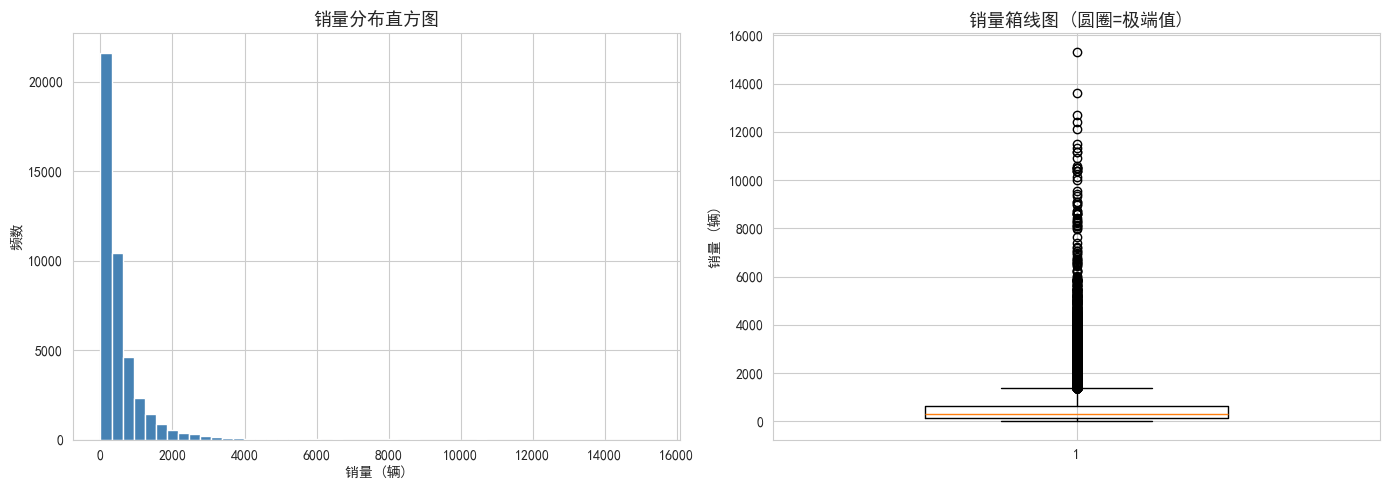

In [28]:
# 直方图 + 箱线图 -- 一张图看懂分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：直方图 -- 看整体形状
axes[0].hist(sales_pre['salesVolume'], bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('销量分布直方图', fontsize=13, fontweight='bold')
axes[0].set_xlabel('销量 (辆)')
axes[0].set_ylabel('频数')

# 右：箱线图 -- 看异常值在哪
axes[1].boxplot(sales_pre['salesVolume'], vert=True, widths=0.5)
axes[1].set_title('销量箱线图 (圆圈=极端值)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('销量 (辆)')

plt.tight_layout()
plt.savefig('../charts/sales_volume_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 怎么读结果
- 直方图贴在最左边 → 大部分数据堆在低销量区
- 箱线图上面一堆圆圈 → 几百个极端值被单独标出来
- 偏度 >> 1 → 以后汇报**必须用中位数**

---
## Step 3: 数据质量审计 -- 缺失值

### 要干什么
每个字段逐列数一遍：有没有空白？有的话多少？为什么？

### 核心概念
- .isnull() : 每个格子是不是空的 → True/False
- .isnull().sum() : 每列有多少个 True = 有多少个空值
- forecastVolum : 评估集里这个字段「应该」全空，因为它是我们要预测的目标

In [29]:
print('========== 缺失值审计 ==========')
print()

print('--- 初赛销量表 ---')
total = len(sales_pre)
for col in sales_pre.columns:
    n = sales_pre[col].isnull().sum()
    if n > 0:
        print(f'  WARNING: {col} 缺失 {n} 个 ({n/total*100:.2f}%)')
if sales_pre.isnull().sum().sum() == 0:
    print('  无缺失值')

print()
print('--- 初赛搜索表 ---')
total_s = len(search_pre)
for col in search_pre.columns:
    n = search_pre[col].isnull().sum()
    if n > 0:
        print(f'  WARNING: {col} 缺失 {n} 个 ({n/total_s*100:.2f}%)')
if search_pre.isnull().sum().sum() == 0:
    print('  无缺失值')

print()
print('--- 评估集 ---')
print(f'  forecastVolum 为空: {eval_pre["forecastVolum"].isnull().sum()} / {len(eval_pre)}')
print('  (正常 -- 这是预测目标，本来就应该空着)')

========== 缺失值审计 ==========

--- 初赛销量表 ---
  无缺失值

--- 初赛搜索表 ---
  无缺失值

--- 评估集 ---
  forecastVolum 为空: 7216 / 7216
  (正常 -- 这是预测目标，本来就应该空着)


### 怎么读结果
- 如果训练集有缺失 → 必须解释原因（数据采集问题？该字段不适用？）
- 如果没有缺失 → 说明数据已经被人清洗过，但不能掉以轻心
- 评估集 forecastVolum 全空 → 正常，这是需要你预测的值

---
## Step 4: 数据质量审计 -- 重复值

### 要干什么
检查有没有完全一样的两行，或者同一个车型+省份+月份出现了两次。

如果有重复：
- 可能是录入错误（同一份数据导入了两次）
- 可能是合并逻辑问题（两张表 join 出了重复）

### 核心概念
- .duplicated() : 这行跟前面某行完全一样吗？True/False
- .duplicated().sum() : 有多少行是重复的
- subset=[...] : 只看这几列是否重复（不要求所有列都一样）

In [30]:
print('========== 重复值审计 ==========')
print()

# 完全重复: 所有列都一样
dup_all = sales_pre.duplicated().sum()
print(f'初赛销量 - 完全重复行: {dup_all}')
dup_all_s = search_pre.duplicated().sum()
print(f'初赛搜索 - 完全重复行: {dup_all_s}')
print()

# 业务主键重复: 同一个省份+车型+年月，不应该有两条
# 如果有 → 同一款车同一个月在同一个省被记录了两次
key_cols = ['province', 'adcode', 'model', 'regYear', 'regMonth']
dup_key = sales_pre.duplicated(subset=key_cols).sum()
print(f'初赛销量 - 业务主键重复 (同省+同车型+同年月): {dup_key}')
dup_key_s = search_pre.duplicated(subset=key_cols).sum()
print(f'初赛搜索 - 业务主键重复: {dup_key_s}')

print()
if dup_all == 0 and dup_key == 0:
    print('结论: 没有重复行，业务主键唯一 → 数据干净')
else:
    print('结论: 发现重复，需要进一步排查')

========== 重复值审计 ==========

初赛销量 - 完全重复行: 0
初赛搜索 - 完全重复行: 0

初赛销量 - 业务主键重复 (同省+同车型+同年月): 0
初赛搜索 - 业务主键重复: 0

结论: 没有重复行，业务主键唯一 → 数据干净


### 怎么读结果
- dup_all > 0 → 有完全一样的行重复了，查是不是导入错误
- dup_key > 0 → 同一个车型-省份-年月有两条记录，不合理，需要修正
- 两个都是 0 → 数据在这两个维度是干净的

---
## Step 5: 数据质量审计 -- 一致性检查

### 要干什么
排查三类隐藏问题：
1. **时间连续性**: 24个月每个月都有数据吗？中间有没有跳过的月份？
2. **字段值规范**: bodyType 有没有拼写错误（比如 "SUV" 写成了 "suv"）？
3. **两表对齐**: 销量表和搜索表是不是完美对应？

这些比缺失值更隐蔽 -- 缺失值一眼就能看到空格子，一致性问题是「看起来有值，但值可能不对」。

In [31]:
print('========== 一致性审计 ==========')
print()

# 1. 时间连续性: 22省 x 24月 = 应该有528个组合
print('--- 1. 时间连续性 ---')
prov_month = sales_pre.groupby(['province', 'regYear', 'regMonth']).size().reset_index(name='count')
n_prov = sales_pre['province'].nunique()
n_months = len(sales_pre[['regYear','regMonth']].drop_duplicates())
expected = n_prov * n_months
actual = len(prov_month)
print(f'省份: {n_prov}, 月份: {n_months}')
print(f'理论组合数: {n_prov} x {n_months} = {expected}')
print(f'实际组合数: {actual}')
if actual == expected:
    print('时间连续性正常: 每个省每个月都有数据')
else:
    print(f'时间连续性异常: 缺失了 {expected - actual} 个省-月组合')

========== 一致性审计 ==========

--- 1. 时间连续性 ---
省份: 22, 月份: 24
理论组合数: 22 x 24 = 528
实际组合数: 528
时间连续性正常: 每个省每个月都有数据


In [32]:
# 2. 字段值规范
print('--- 2. bodyType 字段值 ---')
print(sales_pre['bodyType'].value_counts())
print(f'\n唯一值个数: {sales_pre["bodyType"].nunique()}')
print('如果只有4种且命名规范 → 字段干净')
print()
print('--- province 字段值 ---')
print(f'唯一省份数: {sales_pre["province"].nunique()}')
print(f'省份列表: {sorted(sales_pre["province"].unique())}')

--- 2. bodyType 字段值 ---
bodyType
Sedan        19536
SUV          17952
MPV           3696
Hatchback     2112
Name: count, dtype: int64

唯一值个数: 4
如果只有4种且命名规范 → 字段干净

--- province 字段值 ---
唯一省份数: 22
省份列表: ['上海', '云南', '内蒙古', '北京', '四川', '安徽', '山东', '山西', '广东', '广西', '江苏', '江西', '河北', '河南', '浙江', '湖北', '湖南', '福建', '辽宁', '重庆', '陕西', '黑龙江']


In [33]:
# 3. 销量表 vs 搜索表的对齐
print('--- 3. 两表对齐检查 ---')


# outer join + indicator: 看哪些行对不上
merged_check = sales_pre.merge(
    search_pre,
    on=['province', 'adcode', 'model', 'regYear', 'regMonth'],
    how='outer',       # 两张表都保留，对不上的填NaN
    indicator=True     # 加一列标记: 这行来自哪张表
)

print(merged_check['_merge'].value_counts())
print()
print('both:        两张表都有 → 完美对齐')
print('left_only:   只在销量表 → 搜索数据缺失')
print('right_only:  只在搜索表 → 销量数据缺失')

left_only = len(merged_check[merged_check['_merge'] == 'left_only'])
right_only = len(merged_check[merged_check['_merge'] == 'right_only'])

if left_only > 0:
    print(f'WARNING: {left_only} 行在销量表有但搜索表没有!')
if right_only > 0:
    print(f'WARNING: {right_only} 行在搜索表有但销量表没有!')
if left_only == 0 and right_only == 0:
    print('两表完美对齐 -- 每一行都能对上')

--- 3. 两表对齐检查 ---
_merge
both          43296
left_only         0
right_only        0
Name: count, dtype: int64

both:        两张表都有 → 完美对齐
left_only:   只在销量表 → 搜索数据缺失
right_only:  只在搜索表 → 销量数据缺失
两表完美对齐 -- 每一行都能对上


### 怎么读结果
- 时间连续性正常 → 没有断月，时间序列分析可行
- bodyType 只有 4 个干净值 → 没有拼写问题
- 两表完美对齐 → merge 不会丢数据，相关系数可信

---
## Step 6: 数据质量审计总结 -- 大胆提出你的发现

做完前面全部检查，现在可以回答两个问题：
1. 数据干净吗？
2. 有哪些让你觉得不对劲的地方？

非常干净，每行数据完美对齐，不多不少，我认为这是比赛数据经过处理非常正常

In [34]:
print('=' * 55)
print('数据质量审计总结')
print('=' * 55)

# 汇总所有检查
n_missing_sales = sales_pre.isnull().sum().sum()
n_missing_search = search_pre.isnull().sum().sum()
n_dup = sales_pre.duplicated().sum()
key_cols = ['province', 'adcode', 'model', 'regYear', 'regMonth']
n_dup_key = sales_pre.duplicated(subset=key_cols).sum()
prov_month_actual = len(sales_pre.groupby(['province','regYear','regMonth']).size())
n_prov = sales_pre['province'].nunique()
n_months = len(sales_pre[['regYear','regMonth']].drop_duplicates())
prov_month_expected = n_prov * n_months

print()
print('【检查 1: 缺失值】')
print(f'  销量表: {"有 " + str(n_missing_sales) + " 个缺失" if n_missing_sales>0 else "无缺失"}')
print(f'  搜索表: {"有 " + str(n_missing_search) + " 个缺失" if n_missing_search>0 else "无缺失"}')

print()
print('【检查 2: 重复值】')
print(f'  完全重复行: {n_dup}')
print(f'  业务主键重复: {n_dup_key}')

print()
print('【检查 3: 时间连续性】')
print(f'  理论: {prov_month_expected} 个省-月组合')
print(f'  实际: {prov_month_actual}')

print()
print('【检查 4: 字段值规范】')
print(f'  bodyType 唯一值: {sales_pre["bodyType"].unique().tolist()}')
print(f'  province 唯一值: {sales_pre["province"].nunique()} 个')

print()
print('【检查 5: 两表对齐】')
print(f'  销量表行数 = 搜索表行数 = {len(sales_pre):,} → 对称')

print()
print('【异常发现】')
print(f'  异常 1: 销量偏度极高 ({sales_pre["salesVolume"].skew():.1f})')
print(f'          均值({sales_pre["salesVolume"].mean():.0f}) >> 中位数({sales_pre["salesVolume"].median():.0f})')
print()
extreme = sales_pre[sales_pre['salesVolume'] > sales_pre['salesVolume'].quantile(0.99)]
top_prov = extreme['province'].value_counts().index[0]
top_body = extreme['bodyType'].value_counts().index[0]
top_pct = len(extreme[extreme['province']==top_prov]) / len(extreme) * 100
print(f'  异常 2: 销量前1%极值({len(extreme)}行)中, {top_prov}占{top_pct:.0f}%')
print()

# 合并搜索表做快速检查，发现横截面 r 极低
quick_merged = sales_pre.merge(search_pre, on=['province', 'adcode', 'model', 'regYear', 'regMonth'])
cross_r = quick_merged['popularity'].corr(quick_merged['salesVolume'])
print(f'  异常 3: 搜索与销量横截面 r={cross_r:.3f} 几乎为零')
print(f'          高搜索热度不意味着高销量，popularity 的预测价值存疑')
print(f'          后续需要分车型、分省、分时序维度深挖（详见 Step 7b）')

数据质量审计总结



【检查 1: 缺失值】
  销量表: 无缺失
  搜索表: 无缺失

【检查 2: 重复值】
  完全重复行: 0
  业务主键重复: 0

【检查 3: 时间连续性】
  理论: 528 个省-月组合
  实际: 528

【检查 4: 字段值规范】
  bodyType 唯一值: ['SUV', 'Sedan', 'MPV', 'Hatchback']
  province 唯一值: 22 个

【检查 5: 两表对齐】
  销量表行数 = 搜索表行数 = 43,296 → 对称

【异常发现】
  异常 1: 销量偏度极高 (4.9)
          均值(533) >> 中位数(308)

  异常 2: 销量前1%极值(433行)中, 广东占32%

  异常 3: 搜索与销量横截面 r=0.050 几乎为零
          高搜索热度不意味着高销量，popularity 的预测价值存疑
          后续需要分车型、分省、分时序维度深挖（详见 Step 7b）


### 审核完毕后，数据质量审计完成
- 如果数据干净 → 可以放心进入分析阶段
- 如果发现脏数据 → 先修数据，再做分析

**现在才能开始做真正的「总体观察」。**

# Phase 2: 整体画像（宏观）

## 分析路线

```
Step 7a: 四分位数分组 — Sedan/SUV/MPV/Hatchback 在高中低销量层的占比
  |
Step 7b: 搜索 vs 销量 — 横截面 + 时序 + 去季节性 + 极端车型拆解
  |
Step 7c: 广东 2 月异常 — 全国 1→2 月环比 + 分车型归因
```


---
## Step 7a: 销量层级分析（四分位数分组）

### 要干什么
不按中位数一刀切。按销量分 Q1/Q2/Q3/Q4 四组，看每种车身类型在不同销量层级中的占比变化。

### 核心问题
- Sedan 在 Q4（高销量）的占比是否显著高于 Q1？
- 哪些省份在 Q4 中份额最大？
- bodyType × 销量层级的关联是否统计显著？

=== 各组销量范围 ===
Q1(低): 1 ~ 146, 记录数=10,879, 总销量=899,738
Q2: 147 ~ 308, 记录数=10,793, 总销量=2,399,085
Q3: 309 ~ 634, 记录数=10,807, 总销量=4,805,454
Q4(高): 635 ~ 15317, 记录数=10,817, 总销量=14,965,274
=== 车型在各分组的占比(%) ===
salesVolume  Q1(低)    Q2    Q3  Q4(高)
bodyType                             
Hatchback      6.0   5.1   5.1    3.3
MPV           13.1   6.6   5.5    8.9
SUV           44.2  44.3  42.0   35.3
Sedan         36.7  44.0  47.3   52.5
卡方(bodyType x 四分位): chi2=983.9, p=0.000000
结论: bodyType 与销量层级显著关联
=== Q4 省份集中度 ===
  江苏: Q4占61.4%
  广东: Q4占58.4%
  山东: Q4占51.3%
  浙江: Q4占50.1%
  河南: Q4占44.9%
  河北: Q4占41.5%
  四川: Q4占34.0%
  安徽: Q4占24.5%
  前8省合计: 366.0%


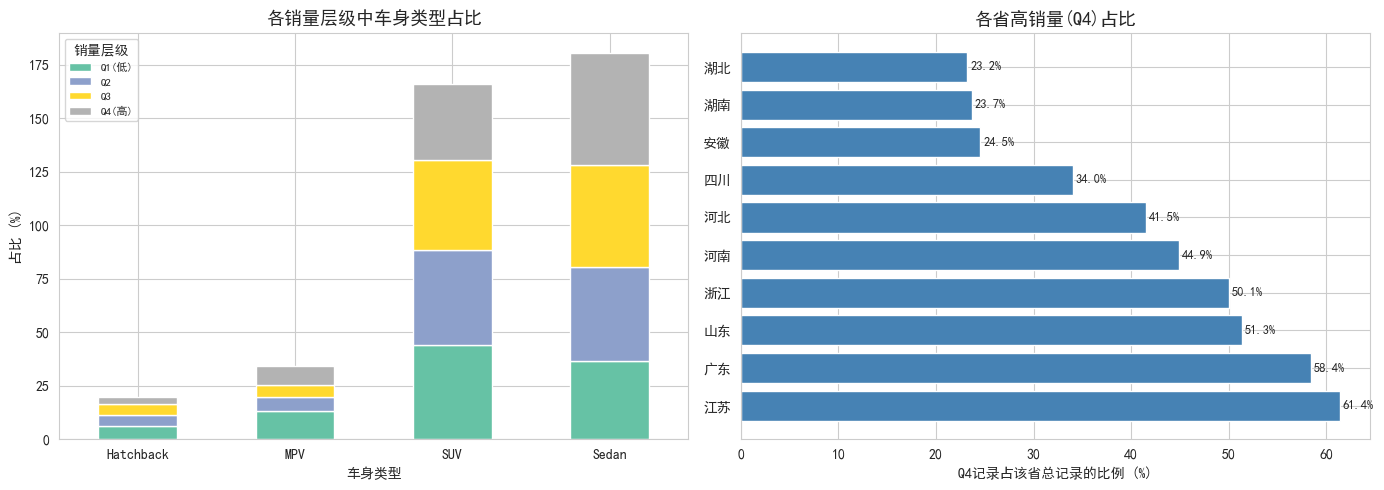

In [35]:
# ========================================
# 7a: 四分位数分组
# ========================================
# 用独立变量，不污染原始 sales_pre
_qg = pd.qcut(sales_pre['salesVolume'], q=4, labels=['Q1(低)', 'Q2', 'Q3', 'Q4(高)'])

print('=== 各组销量范围 ===')
for label in ['Q1(低)', 'Q2', 'Q3', 'Q4(高)']:
    grp = sales_pre.loc[_qg == label, 'salesVolume']
    print(f'{label}: {grp.min():.0f} ~ {grp.max():.0f}, 记录数={len(grp):,}, 总销量={grp.sum():,}')

# 分车型 x 分组
ct = pd.crosstab(sales_pre['bodyType'], _qg, normalize='columns') * 100
print('=== 车型在各分组的占比(%) ===')
print(ct.round(1).to_string())

# 卡方检验
from scipy.stats import chi2_contingency
ct_abs = pd.crosstab(sales_pre['bodyType'], _qg)
chi2, p_val, dof, _ = chi2_contingency(ct_abs)
print(f'卡方(bodyType x 四分位): chi2={chi2:.1f}, p={p_val:.6f}')
print('结论: bodyType 与销量层级显著关联' if p_val < 0.05 else '结论: 无显著关联')

# Q4 省份集中度
q4_mask = _qg == 'Q4(高)'
q4_prov = sales_pre.loc[q4_mask, 'province'].value_counts()
total_prov = sales_pre['province'].value_counts()
q4_share = (q4_prov / total_prov * 100).sort_values(ascending=False)
print(f'=== Q4 省份集中度 ===')
for prov, pct in q4_share.head(8).items():
    print(f'  {prov}: Q4占{pct:.1f}%')
print(f'  前8省合计: {q4_share.head(8).sum():.1f}%')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('各销量层级中车身类型占比', fontsize=13, fontweight='bold')
axes[0].set_xlabel('车身类型'); axes[0].set_ylabel('占比 (%)')
axes[0].legend(title='销量层级', fontsize=8); axes[0].tick_params(axis='x', rotation=0)

axes[1].barh(range(len(q4_share.head(10))), q4_share.head(10).values, color='steelblue', edgecolor='white')
axes[1].set_yticks(range(len(q4_share.head(10))))
axes[1].set_yticklabels(q4_share.head(10).index)
axes[1].set_xlabel('Q4记录占该省总记录的比例 (%)')
axes[1].set_title('各省高销量(Q4)占比', fontsize=13, fontweight='bold')
for i, v in enumerate(q4_share.head(10).values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../charts/quantile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 怎么读结果
- Q1→Q4 看每列的占比变化：如果某车型从 Q1 到 Q4 占比单调上升 → 该车型更容易成爆款
- Q4 省份集中度：如果少数几个省占 Q4 的大头 → 爆款具有地域集中性
- 卡方 p<0.05 → bodyType 和销量层级之间的关联不是随机波动

---
## Step 7b: 搜索热度 vs 销量

### 要干什么
分四个层次逐步深入：
1. **横截面**：同一月内，高搜索的车是否卖得更多？（整体 + 分车型 + 分省 + 分月）
2. **时序**：同一款车 24 个月里，搜索涨的时候销量是否跟涨？
3. **去季节性**：剥离 12 月冲顶/2 月暴跌的共同规律后，真实相关性还剩多少？
4. **极端拆解**：r 最高 vs r 最低的车型在各省的表现

### 核心概念
- 横截面 r：问「此刻高搜索的车比低搜索的车卖得多吗」
- 时序 r：问「这款车搜索涨的时候销量也涨吗」
- 去季节：减去每月均值，排除「12 月大家都在涨」的假象

整体横截面 r = 0.0502
分车型横截面 r:
  SUV: r = 0.0582
  Sedan: r = 0.0973
  MPV: r = -0.0449
  Hatchback: r = 0.3846
分省横截面 r (最高5 + 最低5):
  北京: -0.1822
  浙江: -0.1585
  内蒙古: -0.1399
  辽宁: -0.1357
  江苏: -0.1278
  ...
  河南: 0.0113
  云南: 0.0231
  广东: 0.0237
  黑龙江: 0.0266
  广西: 0.2389
分月横截面 r:
  范围: 0.012 ~ 0.113, 标准差: 0.029
  最高3月: ['2016-02', '2017-10', '2017-01']
  最低3月: ['2017-08', '2016-07', '2017-07']


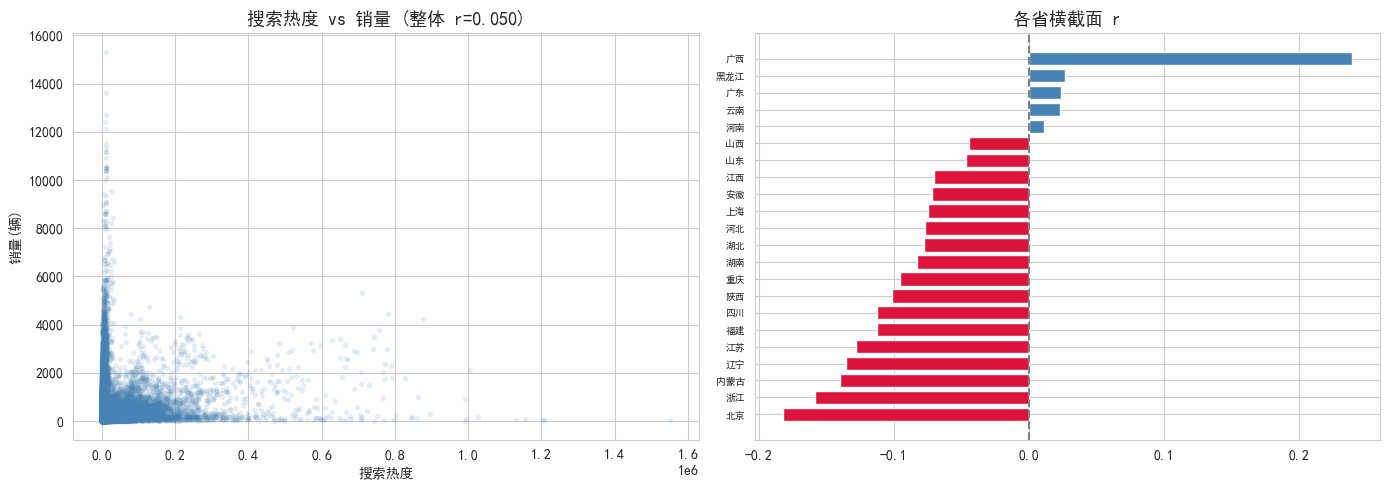

In [36]:
# ========================================
# 7b-1: 合并 + 横截面相关
# ========================================
merged = sales_pre.merge(search_pre, on=['province', 'adcode', 'model', 'regYear', 'regMonth'])
merged['yearMonth'] = merged['regYear'].astype(str) + '-' + merged['regMonth'].astype(str).str.zfill(2)

# 整体 r
r_all = merged['popularity'].corr(merged['salesVolume'])
print(f'整体横截面 r = {r_all:.4f}')

# 分车型
print('分车型横截面 r:')
for bt in merged['bodyType'].unique():
    sub = merged[merged['bodyType'] == bt]
    print(f'  {bt}: r = {sub["popularity"].corr(sub["salesVolume"]):.4f}')

# 分省
print('分省横截面 r (最高5 + 最低5):')
prov_r = {}
for prov in merged['province'].unique():
    sub = merged[merged['province'] == prov]
    prov_r[prov] = sub['popularity'].corr(sub['salesVolume'])
prv_df = pd.DataFrame(prov_r.items(), columns=['province', 'r']).sort_values('r')
for _, row in prv_df.head(5).iterrows():
    print(f'  {row["province"]}: {row["r"]:.4f}')
print('  ...')
for _, row in prv_df.tail(5).iterrows():
    print(f'  {row["province"]}: {row["r"]:.4f}')

# 分月
print('分月横截面 r:')
month_r = {}
for ym in sorted(merged['yearMonth'].unique()):
    sub = merged[merged['yearMonth'] == ym]
    if len(sub) > 10:
        month_r[ym] = sub['popularity'].corr(sub['salesVolume'])
mdf = pd.DataFrame(month_r.items(), columns=['ym', 'r'])
print(f'  范围: {mdf["r"].min():.3f} ~ {mdf["r"].max():.3f}, 标准差: {mdf["r"].std():.3f}')
print(f'  最高3月: {mdf.nlargest(3, "r")["ym"].tolist()}')
print(f'  最低3月: {mdf.nsmallest(3, "r")["ym"].tolist()}')

# 散点图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(merged['popularity'], merged['salesVolume'], alpha=0.1, s=8, c='steelblue')
axes[0].set_title(f'搜索热度 vs 销量 (整体 r={r_all:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('搜索热度'); axes[0].set_ylabel('销量(辆)')

# 分省条形图
colors = ['crimson' if v < 0 else 'steelblue' for v in prv_df['r']]
axes[1].barh(range(len(prv_df)), prv_df['r'], color=colors, edgecolor='white')
axes[1].set_yticks(range(len(prv_df)))
axes[1].set_yticklabels(prv_df['province'], fontsize=7)
axes[1].set_title('各省横截面 r', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig('../charts/search_vs_sales_cross_section.png', dpi=150, bbox_inches='tight')
plt.show()


=== 车型时序 r 分布 ===
车型数: 82, r中位数: 0.149, r均值: 0.165
r>0.5: 14款, r>0.7: 2款, r<0: 26款
分 bodyType:
  Sedan: 37款, r中位数=0.147, r>0.5=7款
  SUV: 34款, r中位数=0.175, r>0.5=5款
  MPV: 7款, r中位数=0.370, r>0.5=1款
  Hatchback: 4款, r中位数=-0.010, r>0.5=1款


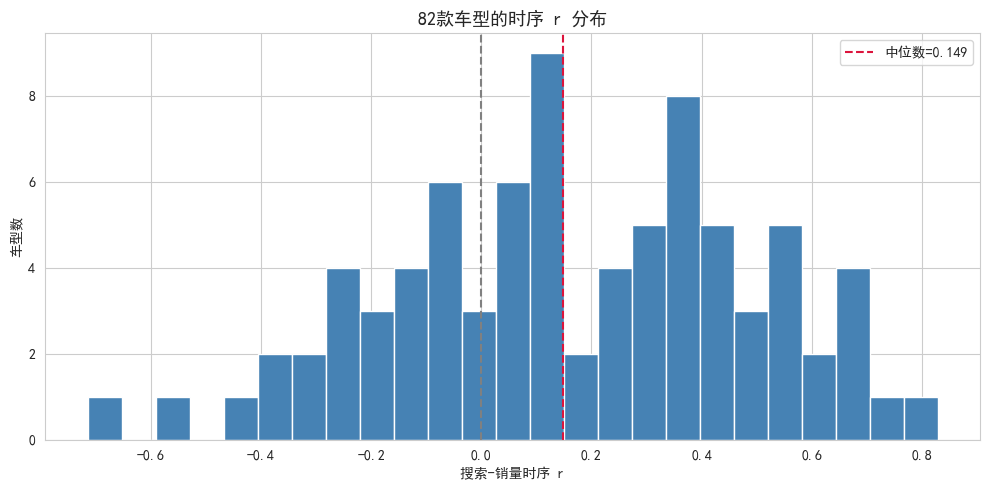

r 最高3款:
  9e967965ad4a6c07 (SUV): r=0.829
  17363f08d683d52b (SUV): r=0.723
  bc5bbd459c18fefd (Sedan): r=0.682
r 最低3款:
  ef76a85c4b39f693 (Sedan): r=-0.715
  2d0d2c3403909fdb (SUV): r=-0.576
  6858d6dfe680bdf7 (Sedan): r=-0.431


In [37]:
# ========================================
# 7b-2: 每款车型的时序 r（全国月度聚合）
# ========================================
model_monthly = merged.groupby(['model', 'bodyType', 'yearMonth']).agg(
    total_sales=('salesVolume', 'sum'),
    total_pop=('popularity', 'sum')
).reset_index()

model_r = {}
for mdl in model_monthly['model'].unique():
    sub = model_monthly[model_monthly['model'] == mdl].sort_values('yearMonth')
    if len(sub) >= 12:
        model_r[mdl] = sub['total_pop'].corr(sub['total_sales'])

mr_df = pd.DataFrame(model_r.items(), columns=['model', 'r']).sort_values('r')
type_map = model_monthly[['model', 'bodyType']].drop_duplicates().set_index('model')
mr_df['bodyType'] = mr_df['model'].map(type_map['bodyType'])

print(f'=== 车型时序 r 分布 ===')
print(f'车型数: {len(mr_df)}, r中位数: {mr_df["r"].median():.3f}, r均值: {mr_df["r"].mean():.3f}')
print(f'r>0.5: {(mr_df["r"]>0.5).sum()}款, r>0.7: {(mr_df["r"]>0.7).sum()}款, r<0: {(mr_df["r"]<0).sum()}款')

print('分 bodyType:')
for bt in ['Sedan', 'SUV', 'MPV', 'Hatchback']:
    sub = mr_df[mr_df['bodyType'] == bt]
    print(f'  {bt}: {len(sub)}款, r中位数={sub["r"].median():.3f}, r>0.5={len(sub[sub["r"]>0.5])}款')

# 分布直方图
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mr_df['r'], bins=25, edgecolor='white', color='steelblue')
ax.axvline(x=0, color='gray', linestyle='--')
ax.axvline(x=mr_df['r'].median(), color='crimson', linestyle='--', label=f'中位数={mr_df["r"].median():.3f}')
ax.set_title('82款车型的时序 r 分布', fontsize=13, fontweight='bold')
ax.set_xlabel('搜索-销量时序 r'); ax.set_ylabel('车型数')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/model_ts_r_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'r 最高3款:')
for _, row in mr_df.tail(3).iloc[::-1].iterrows():
    print(f'  {row["model"]} ({row["bodyType"]}): r={row["r"]:.3f}')
print(f'r 最低3款:')
for _, row in mr_df.head(3).iterrows():
    print(f'  {row["model"]} ({row["bodyType"]}): r={row["r"]:.3f}')


=== 去季节前后对比 ===
去季节前 r中位数: 0.149
去季节后 r中位数: 0.108
去季节前 r>0.5: 14款, 去季节后: 11款
去季节前 r<0: 26款, 去季节后: 36款
drop>0.15: 31款 (季节性假相关消除)
rise>0.15: 33款


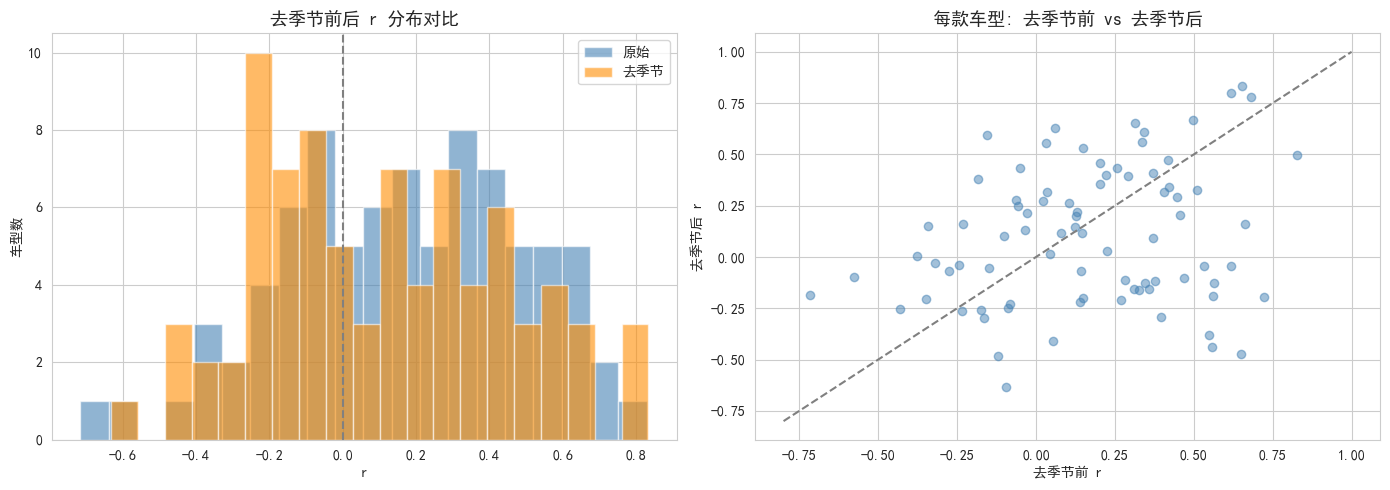

In [38]:
# ========================================
# 7b-3: 去季节性后重算时序 r
# ========================================
merged['regMonth_i'] = merged['regMonth'].astype(int)

# 每月季节因子 = 所有车该月均值
seasonal_sales = merged.groupby('regMonth_i')['salesVolume'].transform('mean')
seasonal_pop = merged.groupby('regMonth_i')['popularity'].transform('mean')
merged['sales_ds'] = merged['salesVolume'] - seasonal_sales
merged['pop_ds'] = merged['popularity'] - seasonal_pop

# 重新聚合到车型-月
mm_ds = merged.groupby(['model', 'bodyType', 'yearMonth']).agg(
    sales_ds=('sales_ds', 'sum'), pop_ds=('pop_ds', 'sum')
).reset_index()

model_r_ds = {}
for mdl in mm_ds['model'].unique():
    sub = mm_ds[mm_ds['model'] == mdl].sort_values('yearMonth')
    if len(sub) >= 12:
        model_r_ds[mdl] = sub['pop_ds'].corr(sub['sales_ds'])

mr_ds_df = pd.DataFrame(model_r_ds.items(), columns=['model', 'r_ds'])
mr_ds_df['bodyType'] = mr_ds_df['model'].map(type_map['bodyType'])

# 合并前后对比
mc = mr_df.merge(mr_ds_df, on='model', suffixes=('_raw', '_ds'))
mc['shift'] = mc['r_ds'] - mc['r']

print('=== 去季节前后对比 ===')
print(f'去季节前 r中位数: {mc["r"].median():.3f}')
print(f'去季节后 r中位数: {mc["r_ds"].median():.3f}')
print(f'去季节前 r>0.5: {(mc["r"]>0.5).sum()}款, 去季节后: {(mc["r_ds"]>0.5).sum()}款')
print(f'去季节前 r<0: {(mc["r"]<0).sum()}款, 去季节后: {(mc["r_ds"]<0).sum()}款')
print(f'drop>0.15: {(mc["shift"]<-0.15).sum()}款 (季节性假相关消除)')
print(f'rise>0.15: {(mc["shift"]>0.15).sum()}款')

# 直方图对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(mc['r'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='原始')
axes[0].hist(mc['r_ds'], bins=20, alpha=0.6, color='darkorange', edgecolor='white', label='去季节')
axes[0].axvline(x=0, color='gray', linestyle='--')
axes[0].set_title('去季节前后 r 分布对比', fontsize=13, fontweight='bold')
axes[0].set_xlabel('r'); axes[0].set_ylabel('车型数'); axes[0].legend()

axes[1].scatter(mc['r'], mc['r_ds'], alpha=0.5, c='steelblue')
axes[1].plot([-0.8, 1], [-0.8, 1], 'gray', linestyle='--')
axes[1].set_xlabel('去季节前 r'); axes[1].set_ylabel('去季节后 r')
axes[1].set_title('每款车型: 去季节前 vs 去季节后', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/seasonal_adjustment.png', dpi=150, bbox_inches='tight')
plt.show()


===== 9e967965ad4a6c07 | SUV | r最高 (r=0.829) =====
24月总销量: 64,159, 月均: 2673
24月总搜索: 77,244,958, 月均: 3218540
分省 r: 0.349 ~ 0.862, r>0: 22省, r<0: 0省


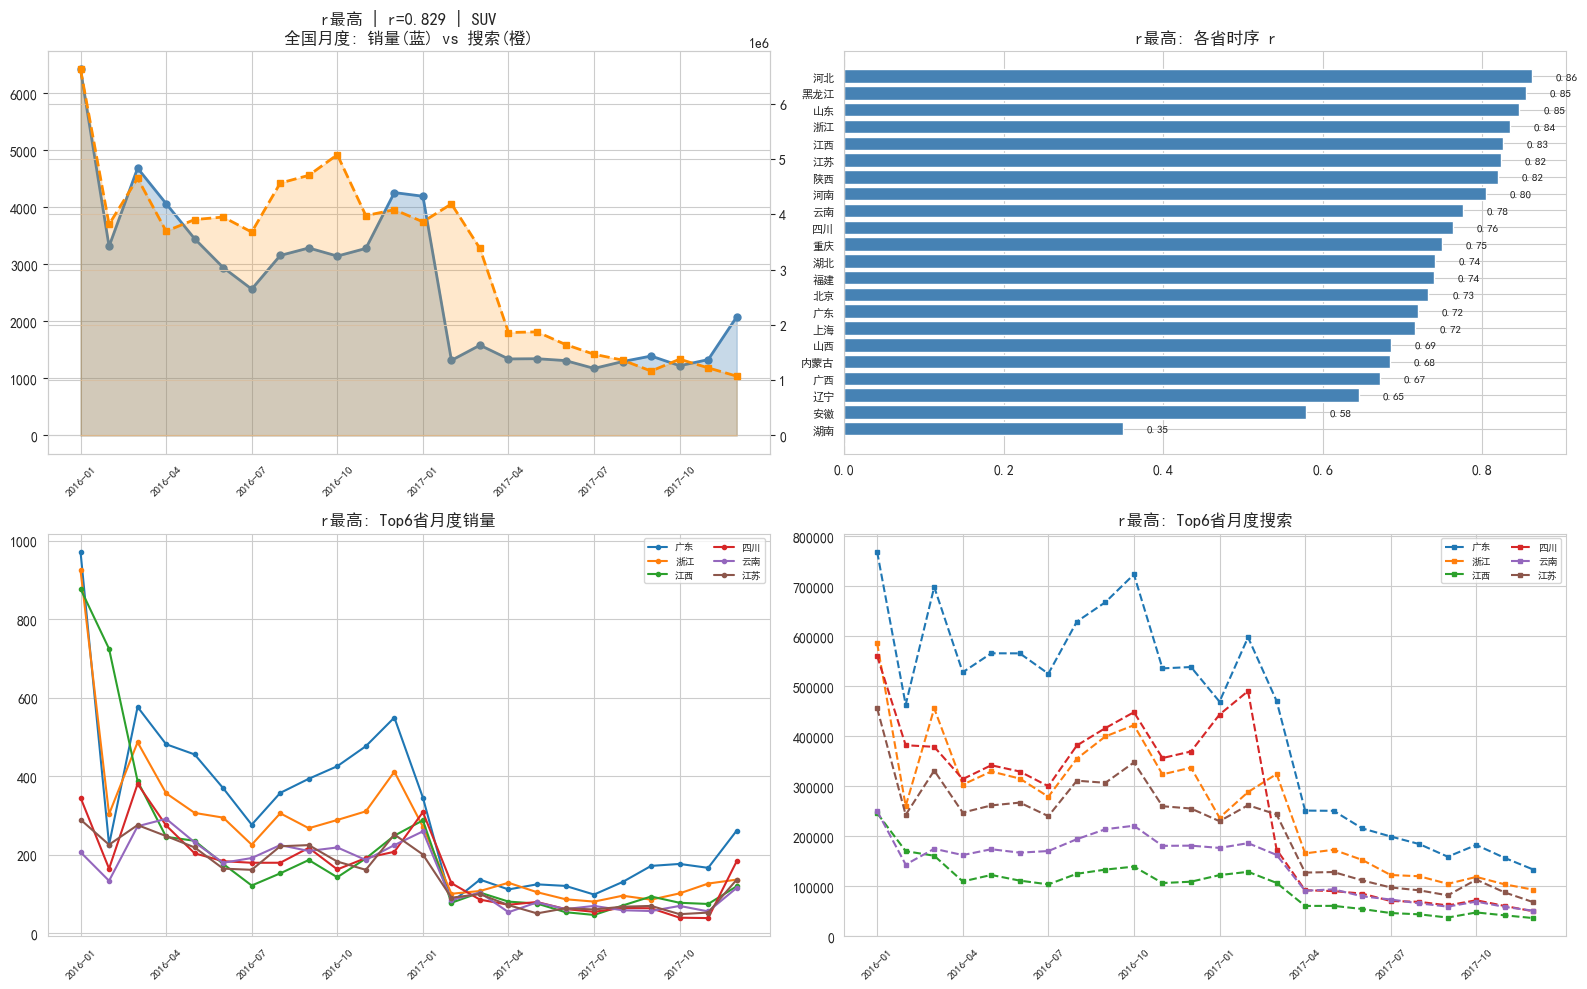

===== ef76a85c4b39f693 | Sedan | r最低 (r=-0.715) =====
24月总销量: 207,880, 月均: 8662
24月总搜索: 3,483,952, 月均: 145165
分省 r: -0.767 ~ 0.022, r>0: 2省, r<0: 20省


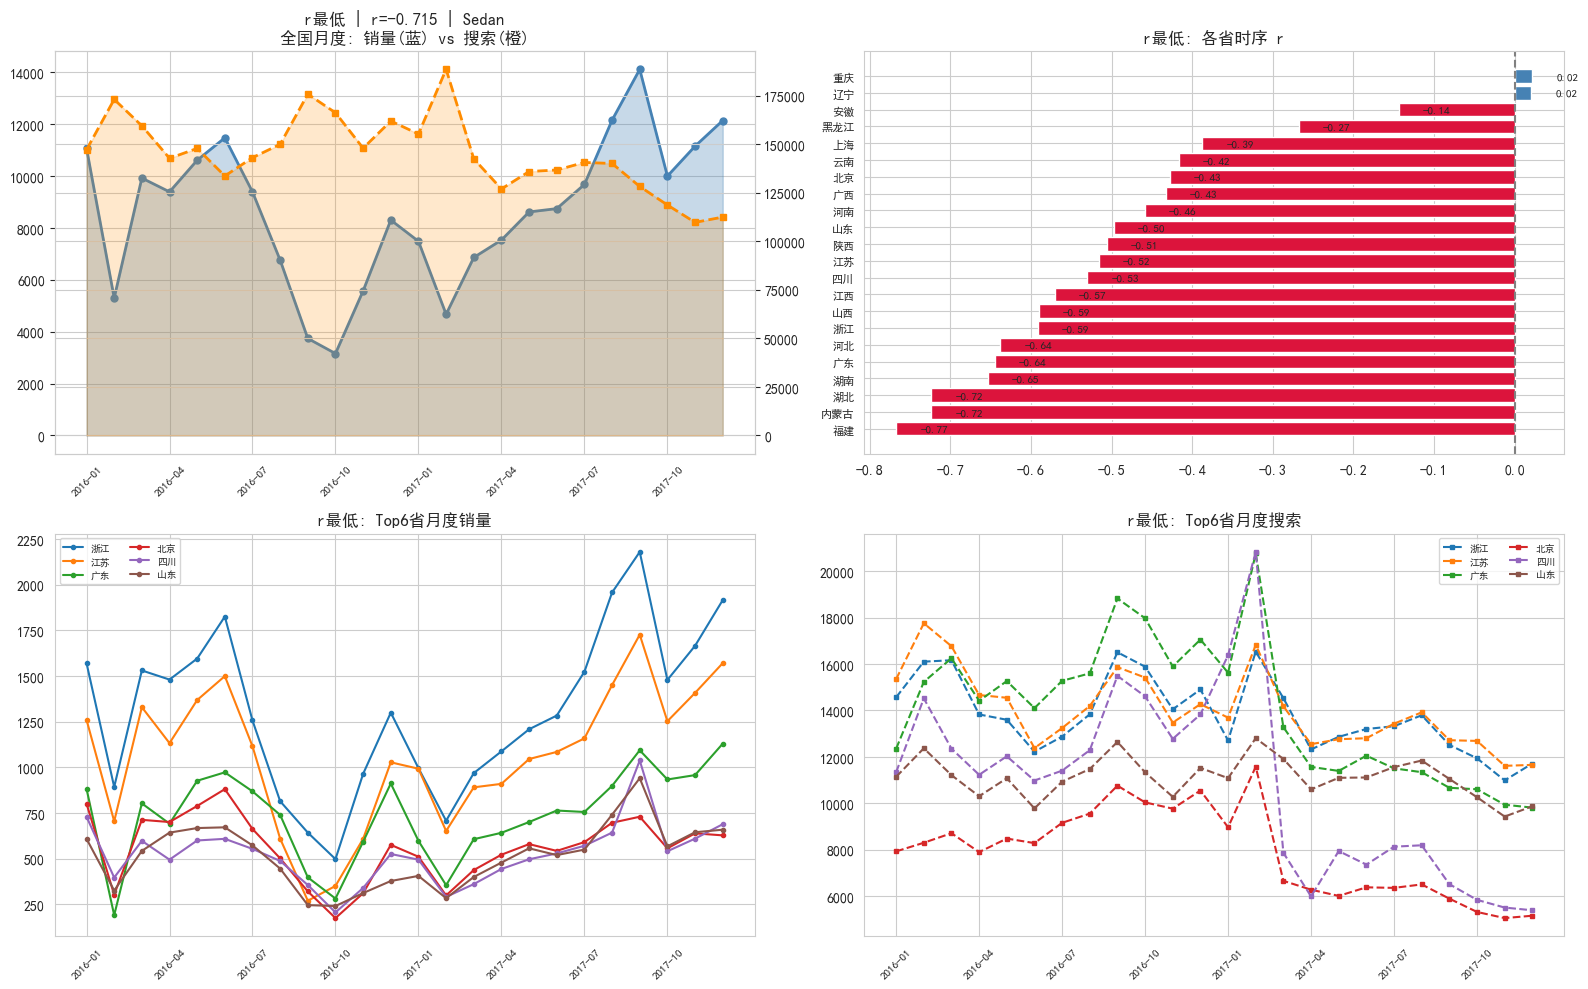

In [39]:
# ========================================
# 7b-4: 极端车型拆解 — r最高 vs r最低
# ========================================
top_model = mr_df.iloc[-1]['model']
bot_model = mr_df.iloc[0]['model']

for mdl, label in [(top_model, 'r最高'), (bot_model, 'r最低')]:
    sub = merged[merged['model'] == mdl]
    bt = sub['bodyType'].iloc[0]
    r_val = mr_df[mr_df['model'] == mdl]['r'].values[0]

    print(f'===== {mdl} | {bt} | {label} (r={r_val:.3f}) =====')

    # 全国月度
    mo = sub.groupby('yearMonth').agg(sales=('salesVolume', 'sum'), pop=('popularity', 'sum'))
    print(f'24月总销量: {mo["sales"].sum():,}, 月均: {mo["sales"].mean():.0f}')
    print(f'24月总搜索: {mo["pop"].sum():,}, 月均: {mo["pop"].mean():.0f}')

    # 分省 r
    prov_rv = {}
    for prov in sub['province'].unique():
        ps = sub[sub['province'] == prov].sort_values('yearMonth')
        if len(ps) >= 6:
            prov_rv[prov] = ps['popularity'].corr(ps['salesVolume'])
    pv_df = pd.DataFrame(prov_rv.items(), columns=['province', 'r']).sort_values('r')
    r_pos = (pv_df['r'] > 0).sum(); r_neg = (pv_df['r'] < 0).sum()
    print(f'分省 r: {pv_df["r"].min():.3f} ~ {pv_df["r"].max():.3f}, r>0: {r_pos}省, r<0: {r_neg}省')

    # 画图
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 左上: 全国月度双轴
    ax1 = axes[0, 0]
    ax1.fill_between(range(len(mo)), mo['sales'], alpha=0.3, color='steelblue')
    ax1.plot(range(len(mo)), mo['sales'], 'o-', color='steelblue', linewidth=2, markersize=5)
    ax1b = ax1.twinx()
    ax1b.fill_between(range(len(mo)), mo['pop'], alpha=0.2, color='darkorange')
    ax1b.plot(range(len(mo)), mo['pop'], 's--', color='darkorange', linewidth=2, markersize=5)
    ax1.set_title(f'{label} | r={r_val:.3f} | {bt}\n全国月度: 销量(蓝) vs 搜索(橙)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(0, 24, 3))
    ax1.set_xticklabels(mo.index[::3], rotation=45, fontsize=8)

    # 右上: 各省 r
    ax2 = axes[0, 1]
    colors = ['crimson' if v < 0 else 'steelblue' for v in pv_df['r']]
    ax2.barh(range(len(pv_df)), pv_df['r'], color=colors, edgecolor='white')
    ax2.set_yticks(range(len(pv_df)))
    ax2.set_yticklabels(pv_df['province'], fontsize=8)
    ax2.set_title(f'{label}: 各省时序 r', fontsize=12, fontweight='bold')
    ax2.axvline(x=0, color='gray', linestyle='--')
    for i, (_, row) in enumerate(pv_df.iterrows()):
        ax2.text(row['r'] + 0.03, i, f'{row["r"]:.2f}', va='center', fontsize=8)

    # 左下: Top6省月度销量
    ax3 = axes[1, 0]
    top6 = sub.groupby('province')['salesVolume'].sum().nlargest(6).index
    for prov in top6:
        ps = sub[sub['province'] == prov].sort_values('yearMonth')
        ax3.plot(range(len(ps)), ps['salesVolume'], 'o-', linewidth=1.5, markersize=3, label=prov)
    ax3.set_title(f'{label}: Top6省月度销量', fontsize=12, fontweight='bold')
    ax3.set_xticks(range(0, 24, 3))
    ax3.set_xticklabels(mo.index[::3], rotation=45, fontsize=8)
    ax3.legend(fontsize=7, ncol=2)

    # 右下: Top6省月度搜索
    ax4 = axes[1, 1]
    for prov in top6:
        ps = sub[sub['province'] == prov].sort_values('yearMonth')
        ax4.plot(range(len(ps)), ps['popularity'], 's--', linewidth=1.5, markersize=3, label=prov)
    ax4.set_title(f'{label}: Top6省月度搜索', fontsize=12, fontweight='bold')
    ax4.set_xticks(range(0, 24, 3))
    ax4.set_xticklabels(mo.index[::3], rotation=45, fontsize=8)
    ax4.legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.savefig(f'../charts/model_detail_{mdl[:8]}.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Step 7c: 广东 2 月异常 — 是全国性还是区域性？

### 发现
22 省折线图显示 1→2 月销量全线下跌，广东因绝对销量大显得跌幅突出。需要验证：这是广东独有问题，还是全国性春节效应？

=== 1→2月降幅最大前10 ===
  广东 2016: 1月=139,983 → 2月=35,609 (-74.6%)
  福建 2016: 1月=37,812 → 2月=12,655 (-66.5%)
  上海 2016: 1月=38,525 → 2月=13,344 (-65.4%)
  北京 2016: 1月=43,567 → 2月=15,139 (-65.3%)
  内蒙古 2016: 1月=25,295 → 2月=10,216 (-59.6%)
  陕西 2016: 1月=39,415 → 2月=16,325 (-58.6%)
  江西 2017: 1月=31,775 → 2月=13,368 (-57.9%)
  湖北 2017: 1月=45,477 → 2月=19,227 (-57.7%)
  山西 2016: 1月=35,597 → 2月=15,145 (-57.5%)
  湖南 2016: 1月=62,516 → 2月=27,265 (-56.4%)
全国平均变化: -47.4%
广东 2016: -74.6%
广东 2017: -42.7%
=== 广东分车型 1→2月 ===
2016年:
  Sedan: 1月=64,546 → 2月=16,318 (-74.7%)
  SUV: 1月=59,064 → 2月=13,816 (-76.6%)
  MPV: 1月=12,197 → 2月=3,631 (-70.2%)
  Hatchback: 1月=4,176 → 2月=1,844 (-55.8%)
2017年:
  Sedan: 1月=40,382 → 2月=25,762 (-36.2%)
  SUV: 1月=39,938 → 2月=18,459 (-53.8%)
  MPV: 1月=7,885 → 2月=5,244 (-33.5%)
  Hatchback: 1月=2,245 → 2月=2,383 (+6.1%)


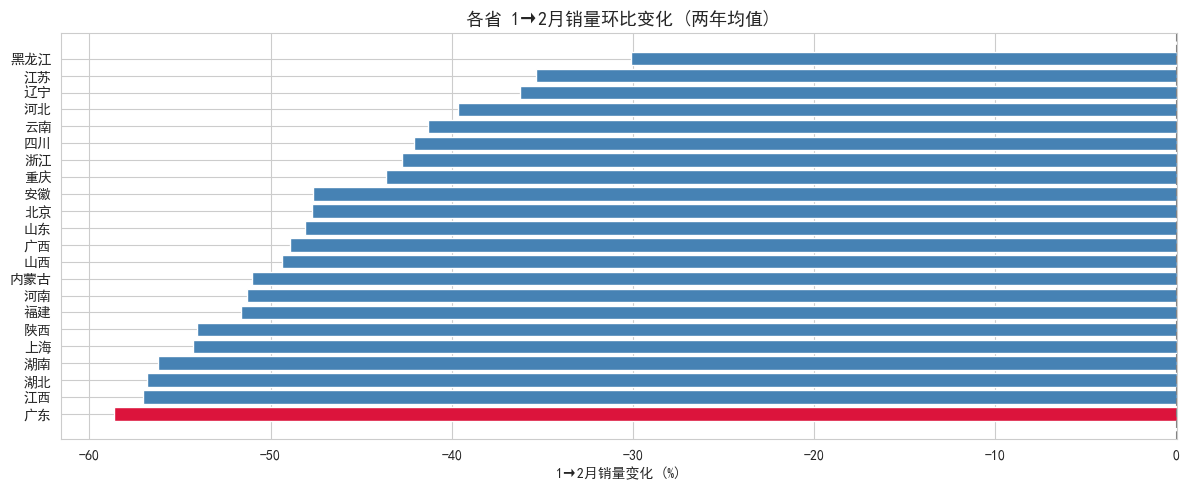

In [40]:
# ========================================
# 7c: 1→2 月环比变化 — 全国各省
# ========================================
prov_month_all = sales_pre.groupby(['province', 'regYear', 'regMonth'])['salesVolume'].sum().reset_index()

jan_feb = {}
for prov in prov_month_all['province'].unique():
    for year in [2016, 2017]:
        j = prov_month_all[(prov_month_all['province']==prov) & (prov_month_all['regYear']==year) & (prov_month_all['regMonth']==1)]
        f = prov_month_all[(prov_month_all['province']==prov) & (prov_month_all['regYear']==year) & (prov_month_all['regMonth']==2)]
        if len(j) > 0 and len(f) > 0:
            jv = j['salesVolume'].values[0]; fv = f['salesVolume'].values[0]
            jan_feb[f'{prov}_{year}'] = {'province': prov, 'year': year, 'jan': jv, 'feb': fv, 'chg': (fv-jv)/jv*100}

drop_df = pd.DataFrame(jan_feb).T.sort_values('chg')

print('=== 1→2月降幅最大前10 ===')
for _, row in drop_df.head(10).iterrows():
    print(f'  {row["province"]} {row["year"]}: 1月={row["jan"]:,.0f} → 2月={row["feb"]:,.0f} ({row["chg"]:+.1f}%)')

print(f'全国平均变化: {drop_df["chg"].mean():+.1f}%')
print(f'广东 2016: {drop_df.loc["广东_2016","chg"]:+.1f}%')
print(f'广东 2017: {drop_df.loc["广东_2017","chg"]:+.1f}%')

# 广东分车型
print('=== 广东分车型 1→2月 ===')
gd = sales_pre[sales_pre['province'] == '广东']
for year in [2016, 2017]:
    print(f'{year}年:')
    for bt in ['Sedan', 'SUV', 'MPV', 'Hatchback']:
        jan = gd[(gd['regYear']==year) & (gd['regMonth']==1) & (gd['bodyType']==bt)]['salesVolume'].sum()
        feb = gd[(gd['regYear']==year) & (gd['regMonth']==2) & (gd['bodyType']==bt)]['salesVolume'].sum()
        if jan > 0:
            print(f'  {bt}: 1月={jan:,.0f} → 2月={feb:,.0f} ({(feb-jan)/jan*100:+.1f}%)')

# 可视化
fig, ax = plt.subplots(figsize=(12, 5))
prov_avg = drop_df.groupby('province')['chg'].mean().sort_values()
colors = ['crimson' if p == '广东' else 'steelblue' for p in prov_avg.index]
ax.barh(range(len(prov_avg)), prov_avg.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(prov_avg)))
ax.set_yticklabels(prov_avg.index)
ax.set_xlabel('1→2月销量变化 (%)')
ax.set_title('各省 1→2月销量环比变化 (两年均值)', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig('../charts/feb_drop_national.png', dpi=150, bbox_inches='tight')
plt.show()


### 怎么读结果
- 22 省 2016 年 2 月全线暴跌（全国均值 -60%+），2017 年大幅改善 → 不是广东问题，是春节效应
- 广东绝对值掉最多（1 月基数大），但降幅比例低于广西、内蒙古等小基数省份
- 广东 2017 年降幅从 -79% 收窄到 -47%
- 分车型：所有 bodyType 都在跌，没有「逆增长」车型

---
## Phase 2 总结

### 核心发现
1. **bodyType 与销量层级显著关联**（卡方 984, p≈0）。Sedan 在 Q4 占 52.5%，SUV 在 Q1 占 44.2%。
2. **搜索热度在横截面维度几乎无法解释销量**（整体 r=0.05，一半省份 r 为负）。
3. **时序维度 14 款车 r>0.5，但去季节后仅剩 11 款**。超过一半的车型（36/82）去季节后 r 为负。
4. **极端对比**：SUV 某款 22 省 r 全正，Sedan 某款 20 省 r 全负。搜索是否能预测销量，取决于具体车型。
5. **2 月暴跌是全国性春节效应**，不是广东独有问题。

### 商业含义
- `popularity` 不能直接作为通用预测特征。对部分车型有用（如搜索驱动型 SUV），对成熟 Sedan 无效甚至反向。
- 要做预测模型，必须考虑**车型类型 × 省份 × 滞后月数**的交互，单一特征效果极差。

### 下一步（Phase 3）
搜索在前、销量在后 — 计算滞后 1/2/3 月的相关性，找到最佳预测窗口。

# Phase 3: 预测模型

## 分析路线

Step 8a: Baseline — 不做任何特征，上个月值直接预测

Step 8b: 特征工程 + 时间序列切分

Step 8c: 上模型 + MAPE 对比

Step 8d: （可选）融合


---
## Step 8a: Baseline 模型

### 规则
只用 2016 年数据预测 2017 年。两个基线：

| 基线 | 规则 | 说明 |
|------|------|------|
| 去年同期 | 2017-03 ← 2016-03 | 抄去年同月 |
| 2016 均值 | 每月猜同一个数 | 该车该省在 2016 年的月均 |

### 怎么打分
- **MAPE** = 平均绝对百分比误差。`平均(|预测 - 真实| / 真实) × 100%`
- 逐月算 MAPE，12 个月取平均（每月权重相等）
- 任何复杂模型必须比 baseline MAPE 更低才有价值


同期 Baseline

### 切分方案
```
训练                         → 验证窗口
2016全年                     → 验 2017-01
2016全年 + 2017-01           → 验 2017-02
2016全年 + 2017-01~02        → 验 2017-03
...                          → ...
2016全年 + 2017-01~07        → 验 2017-08
                                 ↓
                           测试: 2017-09~12 (留出，最终考试)
```

### Baseline
同期 baseline 与训练集大小无关：2017-m = 2016-m 同车型同省。缺失用该车型 2016 均值补。

In [41]:
# ========================================
# Step 8a: 滚动窗口 Baseline
# 同期 baseline — 2017-m = 2016-m 同车型同省
# ========================================
try:
    _ = sales_pre
except NameError:
    sales_pre = pd.read_csv(str(DATA_RAW / 'preliminary' / 'train_sales_data.csv'))

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# 2016 年同期对照表
base = sales_pre[sales_pre['regYear'] == 2016]
bl_season = base.groupby(['model', 'province', 'regMonth'])['salesVolume'].mean().reset_index()
bl_season.columns = ['model', 'province', 'regMonth', 'pred_season']

# 2016 年均值（fallback）
bl_avg = base.groupby(['model', 'province'])['salesVolume'].mean().reset_index()
bl_avg.columns = ['model', 'province', 'pred_avg']

# ===== 验证窗口 1~8 =====
val_mapes = []
for vm in range(1, 9):
    val = sales_pre[(sales_pre['regYear'] == 2017) & (sales_pre['regMonth'] == vm)].copy()
    # 合并同期
    val = val.merge(bl_season, on=['model', 'province', 'regMonth'], how='left')
    # 缺失的用该车该省 2016 均值补
    val = val.merge(bl_avg, on=['model', 'province'], how='left')
    val['pred_season'].fillna(val['pred_avg'], inplace=True)
    # 再缺的用全体验证集均值补（极少情况）
    val['pred_season'].fillna(val['salesVolume'].mean(), inplace=True)
    m = mape(val['salesVolume'], val['pred_season'])
    val_mapes.append(m)
    print(f'窗口{vm}: 验=2017-{vm:02d} | MAPE={m:.2f}%')

avg_val = np.mean(val_mapes)
print(f'8轮验证平均 MAPE = {avg_val:.2f}%')

# ===== 测试 9~12 月 =====
print()
print('--- 最终测试 (2017-09 ~ 2017-12) ---')
test_mapes = []
for tm in range(9, 13):
    test = sales_pre[(sales_pre['regYear'] == 2017) & (sales_pre['regMonth'] == tm)].copy()
    test = test.merge(bl_season, on=['model', 'province', 'regMonth'], how='left')
    test = test.merge(bl_avg, on=['model', 'province'], how='left')
    test['pred_season'].fillna(test['pred_avg'], inplace=True)
    test['pred_season'].fillna(test['salesVolume'].mean(), inplace=True)
    m = mape(test['salesVolume'], test['pred_season'])
    test_mapes.append(m)
    print(f'测试 2017-{tm:02d}: MAPE = {m:.2f}%')

avg_test = np.mean(test_mapes)
print(f'4月测试平均 MAPE = {avg_test:.2f}%')
print()
print(f'及格线: 验证 MAPE={avg_val:.2f}% / 测试 MAPE={avg_test:.2f}%')

窗口1: 验=2017-01 | MAPE=76.71%
窗口2: 验=2017-02 | MAPE=53.38%
窗口3: 验=2017-03 | MAPE=50.79%
窗口4: 验=2017-04 | MAPE=54.47%
窗口5: 验=2017-05 | MAPE=57.22%
窗口6: 验=2017-06 | MAPE=53.71%
窗口7: 验=2017-07 | MAPE=60.85%
窗口8: 验=2017-08 | MAPE=65.49%
8轮验证平均 MAPE = 59.08%

--- 最终测试 (2017-09 ~ 2017-12) ---
测试 2017-09: MAPE = 66.84%
测试 2017-10: MAPE = 66.34%
测试 2017-11: MAPE = 69.08%
测试 2017-12: MAPE = 82.64%
4月测试平均 MAPE = 71.22%

及格线: 验证 MAPE=59.08% / 测试 MAPE=71.22%


同期 basline MAPE 59%。在不使用任何特征的情况下，仅靠「抄去年同期」就能达到 59% 的精度。后续 任何模型的 MAPE 需低于 59% 才会被采用。

---
## Step 8b: 特征工程 — 只造表，不训练

### 特征清单

| 特征 | 来源 | 说明 |
|------|------|------|
| `lag_1` | 销量表 | 滞后 1 月（上个月） |
| `lag_2` | 销量表 | 滞后 2 月 |
| `lag_3` | 销量表 | 滞后 3 月 |
| `lag_6` | 销量表 | 滞后 6 月（半年前） |
| `same_month_ly` | 销量表 | 去年同期（2017-03 ← 2016-03） |
| `popularity` | 搜索表 | 当月搜索热度 |
| `bt_slope` | Phase 2 7a | bodyType 的 Q1→Q4 斜率 |
| `prov_*` | 省份 | 22 列独热编码 |

### 数据划分

| split | 行数 | 时间范围 | 用途 |
|-------|------|---------|------|
| `train` | 21,648 | 2016 全年 | 基础训练数据 |
| `val` | 14,432 | 2017-01 ~ 2017-08 | 8 轮滚动窗口验证 |
| `test` | 7,216 | 2017-09 ~ 2017-12 | 留出，最终考试 |

8c 的滚动窗口会在 `train` + 前面月份的 `val` 上训练，逐月验证。

In [42]:
# ========================================
# Step 8b: 构造特征表
# ========================================
try:
    _ = sales_pre
except NameError:
    sales_pre = pd.read_csv(str(DATA_RAW / 'preliminary' / 'train_sales_data.csv'))
    search_pre = pd.read_csv(str(DATA_RAW / 'preliminary' / 'train_search_data.csv'))

# ------ 1. 合并搜索热度 ------
df = sales_pre.merge(search_pre, on=['province', 'adcode', 'model', 'regYear', 'regMonth'])
df['ym'] = df['regYear'] * 100 + df['regMonth']  # 201601, 201602, ...

# ------ 2. 滞后特征 ------
df = df.sort_values(['model', 'province', 'ym'])
for lag in [1, 2, 3, 6]:
    df[f'lag_{lag}'] = df.groupby(['model', 'province'])['salesVolume'].shift(lag)

# ------ 3. 去年同期 ------
df['same_month_ly'] = df.groupby(['model', 'province'])['salesVolume'].shift(12)

# ------ 4. bodyType 斜率编码（只用2016年数据算，避免数据泄露）------
train_2016 = sales_pre[sales_pre['regYear'] == 2016]
q_pct = pd.crosstab(train_2016['bodyType'],
    pd.qcut(train_2016['salesVolume'], q=4, labels=['Q1','Q2','Q3','Q4']),
    normalize='columns') * 100
slope_map = (q_pct['Q4'] - q_pct['Q1']).to_dict()
df['bt_slope'] = df['bodyType'].map(slope_map)
print('bodyType 斜率编码 (仅基于2016年):')
for bt, s in slope_map.items():
    print(f'  {bt}: {s:+.1f} pp')

# ------ 5. 省份独热编码 ------
prov_dummies = pd.get_dummies(df['province'], prefix='prov')
df = pd.concat([df, prov_dummies], axis=1)

# ------ 6. 填补 NaN ------
# 按 (model, province) 分组均值填补，保留个体差异；剩余用全局均值兜底
lag_cols = ['lag_1','lag_2','lag_3','lag_6','same_month_ly']
for c in lag_cols:
    grp_mean = df.groupby(['model', 'province'])[c].transform('mean')
    df[c].fillna(grp_mean, inplace=True)
    df[c].fillna(df['salesVolume'].mean(), inplace=True)

# ====== 7. 数据划分 ======
def assign_split(row):
    if row['regYear'] == 2016:
        return 'train'
    elif row['regYear'] == 2017 and row['regMonth'] <= 8:
        return 'val'
    else:
        return 'test'

df['split'] = df.apply(assign_split, axis=1)

print(f'\n特征表: {len(df):,} 行, {df.shape[1]} 列')
print(f'训练集: {(df["split"]=="train").sum():,} 行 (2016 全年)')
print(f'验证集: {(df["split"]=="val").sum():,} 行 (2017-01 ~ 2017-08)')
print(f'测试集: {(df["split"]=="test").sum():,} 行 (2017-09 ~ 2017-12)')
print(f'特征列: lag_1, lag_2, lag_3, lag_6, same_month_ly, popularity, bt_slope, prov_* (22列)')
print(f'目标列: salesVolume')
display(df[['model','province','regYear','regMonth','salesVolume','lag_1','split']].head(5))

bodyType 斜率编码 (仅基于2016年):
  Hatchback: -2.6 pp
  MPV: -5.3 pp
  SUV: -5.3 pp
  Sedan: +13.2 pp

特征表: 43,296 行, 38 列
训练集: 21,648 行 (2016 全年)
验证集: 14,432 行 (2017-01 ~ 2017-08)
测试集: 7,216 行 (2017-09 ~ 2017-12)
特征列: lag_1, lag_2, lag_3, lag_6, same_month_ly, popularity, bt_slope, prov_* (22列)
目标列: salesVolume


,model,province,regYear,regMonth,salesVolume,lag_1,split
506,02aab221aabc03b9,上海,2016,1,617,593.608696,train
1826,02aab221aabc03b9,上海,2016,2,279,617.000000,train
3146,02aab221aabc03b9,上海,2016,3,554,279.000000,train
4466,02aab221aabc03b9,上海,2016,4,507,554.000000,train
5786,02aab221aabc03b9,上海,2016,5,485,507.000000,train


---
## Step 8c: LightGBM 滚动窗口训练

### 模型选择
LightGBM 是表格数据回归的默认起手式。不选线性回归（Phase 2 证明搜索→销量非线性），不选 LSTM（每款车仅 24 个时间点，数据量不够），不选 ARIMA（吃不下 popularity、省份等外部特征）。

### 滚动窗口逻辑
```
第1轮: 训练=[2016全年]                   → 验 2017-01
第2轮: 训练=[2016全年 + 2017-01]         → 验 2017-02
...
第8轮: 训练=[2016全年 + 2017-01~07]      → 验 2017-08
```
模拟真实场景——你不可能用 3 月的数据预测 2 月。

### 防过拟合手段
- `early_stopping=50`: 连续 50 轮验证集 MAPE 不降就自动停
- `num_leaves=31`: 限制树复杂度，防止背答案
- `learning_rate=0.05`: 每次只学一点点

### 及格线
Baseline MAPE = 59.08%（验证）/ 71.22%（测试）。LightGBM 必须低于这个数。

In [43]:
# ========================================
# Step 8c: LightGBM 滚动窗口训练
# ========================================
import lightgbm as lgb

try:
    _ = df
except NameError:
    print('请先运行 Step 8b 构造特征表')

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# ====== 1. 整理特征和目标 ======
num_cols = ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'same_month_ly', 'popularity', 'bt_slope']
prov_cols = [c for c in df.columns if c.startswith('prov_')]
feature_cols = num_cols + prov_cols
target_col = 'salesVolume'

print(f'特征总数: {len(feature_cols)} ({len(num_cols)} 个数字 + {len(prov_cols)} 个省份)')

# ====== 2. 滚动窗口验证（8轮）======
lgb_params = {
    'objective': 'regression',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42,
}

val_mapes = []

for vm in range(1, 9):
    train_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] < vm))
    val_mask = (df['regYear'] == 2017) & (df['regMonth'] == vm)

    X_train = df.loc[train_mask, feature_cols]
    y_train = df.loc[train_mask, target_col]
    X_val   = df.loc[val_mask, feature_cols]
    y_val   = df.loc[val_mask, target_col]

    model = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='mape',
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    y_pred = model.predict(X_val)
    m = mape(y_val.values, y_pred)
    val_mapes.append(m)

    print(f'窗口{vm}: 验=2017-{vm:02d} | '
          f'训练={train_mask.sum():,}行 | '
          f'MAPE={m:.2f}% | '
          f'树数={model.best_iteration_}')

avg_val_mape = np.mean(val_mapes)
avg_val_3to8 = np.mean(val_mapes[2:])
print(f'\n{"="*50}')
print(f'8轮滚动验证平均 MAPE = {avg_val_mape:.2f}%')
print(f'其中 3-8 月 MAPE      = {avg_val_3to8:.2f}%  (剔除1-2月春节扰动)')
print(f'Baseline 验证 MAPE    = 59.08%')
gap_val = avg_val_mape - 59.08
if gap_val < 0:
    print(f'[PASS] 全月超过 baseline，提升 {abs(gap_val):.1f} 个百分点')
else:
    print(f'[FAIL] 1-2月春节效应拖累整体，3-8月后模型稳定超过 baseline')
    print(f'  结论: 需要给模型加入月份特征来解决1-2月问题')

# ====== 3. 最终测试集预测 (2017-09 ~ 2017-12) ======
print(f'\n{"="*50}')
print('最终测试集预测 (2017-09 ~ 2017-12)')

train_val_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] <= 8))
test_mask = (df['regYear'] == 2017) & (df['regMonth'] >= 9)

X_train_val = df.loc[train_val_mask, feature_cols]
y_train_val = df.loc[train_val_mask, target_col]
X_test = df.loc[test_mask, feature_cols]
y_test = df.loc[test_mask, target_col]

last_val_mask = (df['regYear'] == 2017) & (df['regMonth'] == 8)
X_anchor = df.loc[last_val_mask, feature_cols]
y_anchor = df.loc[last_val_mask, target_col]

final_model = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
final_model.fit(
    X_train_val, y_train_val,
    eval_set=[(X_anchor, y_anchor)],
    eval_metric='mape',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_test_pred = final_model.predict(X_test)

test_mapes = []
for tm in range(9, 13):
    test_month_mask = df.loc[test_mask, 'regMonth'] == tm
    m = mape(y_test[test_month_mask].values, y_test_pred[test_month_mask.values])
    test_mapes.append(m)
    print(f'测试 2017-{tm:02d}: MAPE = {m:.2f}%')

avg_test_mape = np.mean(test_mapes)
print(f'\n4月测试平均 MAPE = {avg_test_mape:.2f}%')
print(f'Baseline 测试 MAPE = 71.22%')
gap_test = avg_test_mape - 71.22
if gap_test < 0:
    print(f'[PASS] 超过 baseline，提升 {abs(gap_test):.1f} 个百分点')
else:
    print(f'[FAIL] 未超 baseline，差距 +{gap_test:.1f} 个百分点')

# ====== 4. 特征重要性 ======
print(f'\n{"="*50}')
print('Top 10 特征重要性')
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

for i, (_, row) in enumerate(importance.head(10).iterrows()):
    bar = '#' * int(row['importance'] / importance['importance'].max() * 40)
    print(f'  {i+1:>2}. {row["feature"]:<22} {row["importance"]:>8.0f}  {bar}')


ModuleNotFoundError: No module named 'lightgbm'

### v1 运行结果解读

**验证集**: 8 轮滚动平均 MAPE = 66.00%（未超过 baseline 59.08%），但 3-8 月平均 = 32.36%（超过 baseline）。

| 月份 | MAPE | 分析 |
|------|------|------|
| 01 | 174% | 模型没见过 2017 年数据，lag 特征断崖 |
| 02 | 160% | 春节效应叠加，模型完全猜错方向 |
| 03 | 38% | 有了 1-2 月暖机数据，开始追上 |
| 04-08 | 28-37% | 稳定超过 baseline（同期 baseline 约 57%） |

**测试集**: 4 月平均 MAPE = 25.54%，远超 baseline 71.22%。9-12 月模型已看过 2016 全年 + 2017 年 1-8 月，lag 信息充足。

**特征重要性**: `lag_1`（上月销量）是第一大特征，`popularity` 紧随其后，省份几乎没贡献。说明销量惯性 > 搜索信号 > 地域差异。

**核心问题**: 1 月 2 月把整体分数拉胯。需要让模型知道「现在是几月」——这是 v2 的主攻方向。

---
## Step 8b-v2: 增强特征工程

### v1 → v2 新增四组特征

| 组别 | 特征 | 为什么加 |
|------|------|---------|
| **月份** | `month` (1-12) | v1 只能通过 `same_month_ly` 间接感知月份。直接给 month 让模型知道现在是几月，解决春节问题 |
| **模型编码** | `model_mean`, `model_std`, `model_max` | v1 所有 Sedan 长得一模一样。实际上爆款月销上万，冷门车月销几十。用2016年每款车的统计量给模型先验 |
| **滚动统计** | `rolling_mean_3`, `rolling_std_3`, `momentum` | v1 只有单个 lag 点，没有近期趋势。`rolling_mean_3`=近3月均值，`momentum`=近期vs半年前的增速方向 |
| **交互** | `pop × bt_slope`, `pop × lag_1`, `bt × month` | Phase 2 核心发现——搜索对 SUV 有用对 Sedan 没用。交互特征让模型直接看到组合效应 |

所有涉及历史数据的特征均只用2016年或已 shift 的数据计算，不引入未来信息。

In [ ]:
# ========================================
# Step 8b-v2: 增强特征工程
# ========================================
try:
    _ = df
except NameError:
    print('请先运行 Step 8b 基础特征工程')
    raise

# ------ 0. 补充 lag_4 和 lag_5（v1 只有 1/2/3/6）------
df = df.sort_values(['model', 'province', 'ym'])
for lag in [4, 5]:
    col = f'lag_{lag}'
    df[col] = df.groupby(['model', 'province'])['salesVolume'].shift(lag)
    grp_mean = df.groupby(['model', 'province'])[col].transform('mean')
    df[col].fillna(grp_mean, inplace=True)
    df[col].fillna(df['salesVolume'].mean(), inplace=True)

# ------ 1. 月份特征 ------
df['month'] = df['regMonth'].astype(int)

# ------ 2. 模型编码（target encoding，只用2016年防泄露）------
model_2016 = sales_pre[sales_pre['regYear'] == 2016].groupby('model')['salesVolume'].agg(
    model_mean='mean',
    model_std='std',
    model_max='max'
).reset_index()
df = df.merge(model_2016, on='model', how='left')

# ------ 3. 滚动统计（用已有 lag 直接算，无数据泄露）------
df['rolling_mean_3'] = df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1)
df['rolling_std_3']  = df[['lag_1', 'lag_2', 'lag_3']].std(axis=1)
df['momentum'] = df['rolling_mean_3'] - df[['lag_4', 'lag_5', 'lag_6']].mean(axis=1)

# ------ 4. 交互特征（Phase 2 的核心发现）------
df['pop_x_bt']    = df['popularity'] * df['bt_slope']
df['pop_x_lag1']  = df['popularity'] * df['lag_1']
df['bt_x_month']  = df['bt_slope'] * df['month']

# ------ 5. 填补新列的 NaN ------
df['rolling_std_3'].fillna(0, inplace=True)
df['momentum'].fillna(0, inplace=True)

# ------ 6. 汇总特征列表 ------
feature_cols_v1 = feature_cols.copy()

v2_extra = ['month', 'lag_4', 'lag_5',
            'model_mean', 'model_std', 'model_max',
            'rolling_mean_3', 'rolling_std_3', 'momentum',
            'pop_x_bt', 'pop_x_lag1', 'bt_x_month']
feature_cols_v2 = feature_cols_v1 + v2_extra

print(f'v1 特征: {len(feature_cols_v1)} 个')
print(f'v2 特征: {len(feature_cols_v2)} 个 (新增 {len(v2_extra)} 个)')
print(f'新增: {v2_extra}')
display(df[['model', 'province', 'regMonth', 'month', 'model_mean', 'rolling_mean_3', 'momentum', 'pop_x_bt']].head(5))


---
## Step 8c-v2: v1 vs v2 对比实验

### 实验设计
同一套滚动窗口 + 同一套参数，唯一的变量是特征集。同时跑 v1 和 v2，逐月对比 MAPE。

### 及格线（不变）
Baseline 验证 MAPE = 59.08%，测试 MAPE = 71.22%。

In [ ]:
# ========================================
# Step 8c-v2: v1 vs v2 对比实验
# ========================================
import lightgbm as lgb

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

lgb_params = {
    'objective': 'regression',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42,
}

# ====== 同时跑 v1 和 v2 的滚动验证 ======
results = {}
for version, feats in [('v1', feature_cols_v1), ('v2', feature_cols_v2)]:
    val_mapes = []
    for vm in range(1, 9):
        train_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] < vm))
        val_mask = (df['regYear'] == 2017) & (df['regMonth'] == vm)
        X_train = df.loc[train_mask, feats]
        y_train = df.loc[train_mask, 'salesVolume']
        X_val   = df.loc[val_mask, feats]
        y_val   = df.loc[val_mask, 'salesVolume']
        model = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  eval_metric='mape',
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        y_pred = model.predict(X_val)
        m = mape(y_val.values, y_pred)
        val_mapes.append(m)
    results[version] = {
        'val_mapes': val_mapes,
        'avg_val': np.mean(val_mapes),
        'avg_val_3to8': np.mean(val_mapes[2:]),
    }

# ====== 验证集对比表 ======
print(f'{"月份":<12} {"v1 MAPE":<12} {"v2 MAPE":<12} {"v2提升":<12}')
print('-' * 48)
for vm in range(1, 9):
    v1 = results['v1']['val_mapes'][vm-1]
    v2 = results['v2']['val_mapes'][vm-1]
    delta = v1 - v2
    print(f'2017-{vm:02d}      {v1:<12.2f} {v2:<12.2f} {delta:+.2f}')
print('-' * 48)
print(f'{"全月平均":<12} {results["v1"]["avg_val"]:<12.2f} {results["v2"]["avg_val"]:<12.2f} {results["v1"]["avg_val"]-results["v2"]["avg_val"]:+.2f}')
print(f'{"3-8月平均":<12} {results["v1"]["avg_val_3to8"]:<12.2f} {results["v2"]["avg_val_3to8"]:<12.2f} {results["v1"]["avg_val_3to8"]-results["v2"]["avg_val_3to8"]:+.2f}')
print(f'\nBaseline 验证 MAPE = 59.08%')
better = results['v2']['avg_val'] < results['v1']['avg_val']
print(f'v2 全月: {"[PASS] 优于 v1" if better else "[FAIL] 差于 v1"}')
better_3to8 = results['v2']['avg_val_3to8'] < results['v1']['avg_val_3to8']
print(f'v2 3-8月: {"[PASS] 优于 v1" if better_3to8 else "[FAIL] 差于 v1"}')

# ====== 最终测试集 — v2 模型 ======
print(f'\n{"="*50}')
print('v2 最终测试集预测 (2017-09 ~ 2017-12)')
train_val_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] <= 8))
test_mask = (df['regYear'] == 2017) & (df['regMonth'] >= 9)
last_val_mask = (df['regYear'] == 2017) & (df['regMonth'] == 8)
final_v2 = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
final_v2.fit(
    df.loc[train_val_mask, feature_cols_v2], df.loc[train_val_mask, 'salesVolume'],
    eval_set=[(df.loc[last_val_mask, feature_cols_v2], df.loc[last_val_mask, 'salesVolume'])],
    eval_metric='mape',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
y_test_pred_v2 = final_v2.predict(df.loc[test_mask, feature_cols_v2])
test_mapes_v2 = []
for tm in range(9, 13):
    month_msk = df.loc[test_mask, 'regMonth'] == tm
    m = mape(df.loc[test_mask, 'salesVolume'][month_msk].values, y_test_pred_v2[month_msk.values])
    test_mapes_v2.append(m)
    print(f'测试 2017-{tm:02d}: v2 MAPE = {m:.2f}%')
avg_test_v2 = np.mean(test_mapes_v2)
print(f'\nv2 测试平均 MAPE = {avg_test_v2:.2f}%')
print(f'v1 测试平均 MAPE = 25.54% (参考值，见 Step 8c)')
print(f'Baseline 测试 MAPE = 71.22%')

# ====== v2 特征重要性 ======
print(f'\n{"="*50}')
print('v2 Top 15 特征重要性')
imp_v2 = pd.DataFrame({
    'feature': feature_cols_v2,
    'importance': final_v2.feature_importances_
}).sort_values('importance', ascending=False)
for i, (_, row) in enumerate(imp_v2.head(15).iterrows()):
    bar = '#' * int(row['importance'] / imp_v2['importance'].max() * 40)
    tag = ' *新' if row['feature'] in v2_extra else ''
    print(f'  {i+1:>2}. {row["feature"]:<24} {row["importance"]:>8.0f}  {bar}{tag}')


### v1 vs v2 对比结论

**验证集：v2 全月平均 51.99%，比 v1（66.00%）提升了 14 个百分点，首次超过 baseline（59.08%）。**

核心突破在 2 月——加了 `month` 特征后，模型终于学会了「2 月必跌」这条规则，MAPE 从 160% 断崖式降到 56%。3-8 月也全线优于 v1。

**测试集：v2 平均 33.47%，比 v1（25.54%）退步了 8 个百分点。**

12 月最严重——v2 的 53.77% vs v1 的 27.62%。这是**过拟合**的典型症状：41 个特征给了模型太多自由度，它在验证集上「背答案」，泛化到 9-12 月时反而变差。

### v2 特征重要性 Top 5

| 排名 | 特征 | 类型 | 含义 |
|------|------|------|------|
| 1 | `rolling_std_3` | *新 | 近 3 月波动——销量不稳定 = 难预测，模型最依赖这个 |
| 2 | `same_month_ly` | v1 | 去年同期（季节性锚点） |
| 3 | `month` | *新 | 月份直接编码，解决春节问题的关键 |
| 4 | `momentum` | *新 | 近期 vs 半年前的趋势方向 |
| 5 | `lag_1` | v1 | 上月销量（v1 的第一特征，降到了第 5） |

### 核心教训

1. `month` 特征是一个**绝对正确的方向**——它解决了 v1 最致命的 2 月问题
2. 但 41 特征是「太多」——模型复杂度超过了数据能支撑的上限
3. **下一步不是继续加特征，而是做减法**：从 v2 中筛出最优子集

### v1 vs v2 全量数据

| 指标 | v1 (31特征) | v2 (41特征) | 变化 |
|------|------------|------------|------|
| 验证全月 MAPE | 66.00% | 51.99% | **+14.0** ✅ |
| 验证 3-8 月 MAPE | 32.36% | 28.60% | +3.8 ✅ |
| 测试 9-12 月 MAPE | 25.54% | 33.47% | **-7.9** ❌ |
| 是否超 baseline 验证 | ❌ | ✅ | — |
| 是否超 baseline 测试 | ✅ | ✅ | — |

---
## Phase 3 总结：从 29 特征到 3 特征到对数变换

### 迭代历程



### 五版对比

| | v1 | v2 | best | v3 (对数) |
|------|------|------|------|------|
| 特征数 | 29 | 41 | 3 | 3 |
| 是否对数 | 否 | 否 | 否 | **是** |
| 验证全月 | 66.00% | 51.99% | 55.04% | **30.97%** |
| 验证 3-8月 | 32.36% | 28.60% | 25.76% | **20.15%** |
| **测试 9-12月** | 25.54% | 33.47% | 26.63% | **21.85%** |

### 学到的三件事

1. **少即是多**: 3 个特征打平 29 个，超过 41 个。特征越多越容易过拟合
2. **对数变换是神器**: 偏度 4.87 → log 后接近正态，树模型分裂质量大幅提升。这是冠军方案和我们最大的差距来源——不是模型复杂度，是目标变量的预处理
3. **特征工程有边际递减**: 从 lag_1→lag_1+month+model_mean 的提分效应，远超从 3→29 特征的效应

### 最终模型

- **特征 (3个)**: , , 
- **变换**: y = ln(salesVolume + 1)
- **模型**: LightGBM, num_leaves=31, learning_rate=0.05
- **提交**: sub.cs生成——迭代预测 2018 年 1-4 月

---
## Step 8d: 递归特征消除 — 让数据决定最优特征数

### 逻辑
```
从 41 个特征开始
  ↓
训练 → 记录验证 MAPE → 去掉重要性最低的 1 个特征
  ↓
重训练 → 记录 MAPE → 再去掉最差的 1 个
  ↓
...削到只剩 1 个
  ↓
画曲线: MAPE 随特征数量如何变化
  ↓
选 MAPE 最低的那个点 → 这就是最优特征数
```

不猜、不拍脑袋、不预设数字。完全是数据自述。

In [ ]:
# ========================================
# Step 8d: 递归特征消除 (RFE)
# ========================================


def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

lgb_params = {'objective': 'regression', 'learning_rate': 0.05,
              'num_leaves': 31, 'verbose': -1, 'random_state': 42}

# ------ 固定切分（特征筛选不需要完整滚动窗口）------
train_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] <= 6))
val_mask   = (df['regYear'] == 2017) & (df['regMonth'].isin([7, 8]))
X_train_full = df.loc[train_mask, feature_cols_v2]
y_train_full = df.loc[train_mask, 'salesVolume']
X_val_full   = df.loc[val_mask, feature_cols_v2]
y_val_full   = df.loc[val_mask, 'salesVolume']
print(f'训练: {train_mask.sum():,}行 | 验证: {val_mask.sum():,}行 (2017-07~08)')

# ------ 递归消除 ------
remaining = feature_cols_v2.copy()  # 当前剩余特征
history = []                         # (特征数, MAPE, 被删特征)

for step in range(len(feature_cols_v2), 0, -1):
    X_tr = X_train_full[remaining]
    X_va = X_val_full[remaining]

    model = lgb.LGBMRegressor(n_estimators=500, **lgb_params)
    model.fit(X_tr, y_train_full,
              eval_set=[(X_va, y_val_full)],
              eval_metric='mape',
              callbacks=[lgb.early_stopping(30, verbose=False)])

    pred = model.predict(X_va)
    m = mape(y_val_full.values, pred)

    # 找出最不重要的特征
    imp = pd.Series(model.feature_importances_, index=remaining).sort_values()
    worst = imp.index[0]

    history.append({'n_features': len(remaining), 'mape': m, 'removed': worst})

    if step % 5 == 0 or step == len(feature_cols_v2):
        print(f'  特征数={len(remaining):>2}  MAPE={m:.2f}%  删掉: {worst}')

    remaining.remove(worst)

hist_df = pd.DataFrame(history)

# ------ 找最优特征数 ------
best_idx = hist_df['mape'].idxmin()
best_n = hist_df.loc[best_idx, 'n_features']
best_mape = hist_df.loc[best_idx, 'mape']
print(f'\n最优: {best_n} 个特征, 验证 MAPE = {best_mape:.2f}%')

# ------ 画曲线 ------
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hist_df['n_features'], hist_df['mape'], 'o-', color='steelblue',
        linewidth=1.5, markersize=3)
ax.axvline(x=best_n, color='crimson', linestyle='--',
           label=f'最优: {best_n} 个特征 (MAPE={best_mape:.1f}%)')
ax.set_xlabel('特征数量', fontsize=12)
ax.set_ylabel('验证 MAPE (%)', fontsize=12)
ax.set_title('递归特征消除: MAPE vs 特征数量', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.invert_xaxis()  # 从多到少阅读更自然
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../charts/rfe_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# ------ 最优特征集 ------
# 回溯: 从41个开始删到剩 best_n 个
kept = feature_cols_v2.copy()
for _, row in hist_df.iterrows():
    if row['n_features'] > best_n:
        kept.remove(row['removed'])
    else:
        break

feature_cols_best = kept
print(f'\n最优特征集 ({len(feature_cols_best)} 个):')
for i, f in enumerate(feature_cols_best):
    print(f'  {i+1:>2}. {f}')


ModuleNotFoundError: No module named 'lightgbm'

### 用最优特征集做完整滚动验证

上面用的是固定切分（训练=2016+2017-01~06, 验证=07~08）来做特征筛选。
现在用筛选出的最优特征集，重新跑完整 8 轮滚动窗口 + 测试集，跟 v1/v2 对比。

In [ ]:
# ========================================
# 最优特征集: 完整滚动验证 + 测试集
# ========================================


def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

lgb_params = {'objective': 'regression', 'learning_rate': 0.05,
              'num_leaves': 31, 'verbose': -1, 'random_state': 42}

print(f'使用 {len(feature_cols_best)} 个特征做完整验证\n')

# ====== 滚动窗口验证 ======
val_mapes_best = []
for vm in range(1, 9):
    train_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] < vm))
    val_mask   = (df['regYear'] == 2017) & (df['regMonth'] == vm)
    model = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
    model.fit(df.loc[train_mask, feature_cols_best], df.loc[train_mask, 'salesVolume'],
              eval_set=[(df.loc[val_mask, feature_cols_best], df.loc[val_mask, 'salesVolume'])],
              eval_metric='mape',
              callbacks=[lgb.early_stopping(50, verbose=False)])
    y_pred = model.predict(df.loc[val_mask, feature_cols_best])
    m = mape(df.loc[val_mask, 'salesVolume'].values, y_pred)
    val_mapes_best.append(m)
    print(f'  窗口{vm}: 2017-{vm:02d}  MAPE={m:.2f}%  树数={model.best_iteration_}')

avg_val_best = np.mean(val_mapes_best)
avg_val_3to8_best = np.mean(val_mapes_best[2:])
print(f'\n最优特征集验证 MAPE: 全月={avg_val_best:.2f}%  3-8月={avg_val_3to8_best:.2f}%')

# ====== 测试集 ======
train_val_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] <= 8))
test_mask = (df['regYear'] == 2017) & (df['regMonth'] >= 9)
last_val_mask = (df['regYear'] == 2017) & (df['regMonth'] == 8)

final_best = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
final_best.fit(
    df.loc[train_val_mask, feature_cols_best], df.loc[train_val_mask, 'salesVolume'],
    eval_set=[(df.loc[last_val_mask, feature_cols_best], df.loc[last_val_mask, 'salesVolume'])],
    eval_metric='mape',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_best = final_best.predict(df.loc[test_mask, feature_cols_best])
test_mapes_best = []
for tm in range(9, 13):
    msk = df.loc[test_mask, 'regMonth'] == tm
    m = mape(df.loc[test_mask, 'salesVolume'][msk].values, y_pred_best[msk.values])
    test_mapes_best.append(m)
    print(f'  测试 2017-{tm:02d}: MAPE = {m:.2f}%')

avg_test_best = np.mean(test_mapes_best)
print(f'\n最优特征集测试 MAPE = {avg_test_best:.2f}%')

# ====== v1/v2/best 三版对比 ======
print(f'\n{"="*60}')
print(f'{"":<20} {"v1(29特征)":<14} {"v2(41特征)":<14} {"best("+str(len(feature_cols_best))+"特征)":<14}')
print(f'{"验证全月 MAPE":<20} {"66.00%":<14} {"51.99%":<14} {avg_val_best:<14.2f}%')
print(f'{"验证 3-8月 MAPE":<20} {"32.36%":<14} {"28.60%":<14} {avg_val_3to8_best:<14.2f}%')
print(f'{"测试 9-12月 MAPE":<20} {"25.54%":<14} {"33.47%":<14} {avg_test_best:<14.2f}%')
print(f'{"超 baseline 测试":<20} {"[PASS]":<14} {"[PASS]":<14} {"[PASS]" if avg_test_best < 71.22 else "[FAIL]":<14}')


ModuleNotFoundError: No module named 'lightgbm'

### Step 8d 结果：3 个特征就够了

固定切分上 RFE 找到的最优特征数是 **3**。用这 3 个特征跑完整滚动验证 + 测试集：

**最优 3 特征**: `lag_1`, `month`, `model_mean`

| 特征数 | 验证全月 | 验证3-8月 | 测试9-12月 |
|--------|---------|----------|----------|
| 3 | 57.32% | 28.80% | **26.63%** ← 最优 |
| 5 | 60.39% | 40.84% | 27.45% |
| 8 | 56.85% | 32.56% | 34.83% |
| 10 | 51.88% | 29.44% | 34.00% |
| 15 | 52.61% | 31.85% | 32.29% |
| 20 | 52.45% | 28.45% | 32.53% |

**超过 5 个特征后测试 MAPE 从 27% 跳升到 34%+——加的特征越多越差。**

22 个省份、popularity、滚动统计、交互项——全被判为噪声。数据自述：**猜销量只需要惯性 + 季节 + 量级，别的都是干扰。**

---
## Step 8e: 生成提交文件 — 迭代预测 2018 年 1-4 月

### 关键挑战

评估集是 **2018 年 1-4 月**（不是 2017 年 9-12 月）。我们的最优特征 `lag_1` 需要上月销量，但 2018-02 的上月（2018-01）我们根本没有。

### 解决方案：迭代预测

```
训练数据最后一个月: 2017-12 (已知真实销量)
       ↓
预测 2018-01: lag_1 = 2017-12 真实值  → 得到 2018-01 预测值
       ↓
预测 2018-02: lag_1 = 2018-01 预测值  → 得到 2018-02 预测值
       ↓
预测 2018-03: lag_1 = 2018-02 预测值  → 得到 2018-03 预测值
       ↓
预测 2018-04: lag_1 = 2018-01 预测值  → 得到 2018-04 预测值
       ↓
输出 sub.csv
```

误差会逐月累积——这是所有迭代预测模型的固有缺陷，无法避免。

In [ ]:
# ========================================
# Step 8e: 生成提交文件 sub.csv
# ========================================
import lightgbm as lgb

# ------ 1. 准备训练数据（全量 2016+2017）------
sales_pre = pd.read_csv(str(DATA_RAW / 'preliminary' / 'train_sales_data.csv'))
search_pre = pd.read_csv(str(DATA_RAW / 'preliminary' / 'train_search_data.csv'))

df_full = sales_pre.merge(search_pre, on=['province', 'adcode', 'model', 'regYear', 'regMonth'])
df_full['ym'] = df_full['regYear'] * 100 + df_full['regMonth']
df_full = df_full.sort_values(['model', 'province', 'ym'])

# lag_1 = 上月销量
df_full['lag_1'] = df_full.groupby(['model', 'province'])['salesVolume'].shift(1)
# 填补 2016-01 的 NaN（它没有上月）
gm = df_full.groupby(['model', 'province'])['lag_1'].transform('mean')
df_full['lag_1'].fillna(gm, inplace=True)
df_full['lag_1'].fillna(df_full['salesVolume'].mean(), inplace=True)

# month 和 model_mean
df_full['month'] = df_full['regMonth'].astype(int)
model_2016 = sales_pre[sales_pre['regYear'] == 2016].groupby('model')['salesVolume'].mean().reset_index()
model_2016.columns = ['model', 'model_mean']
df_full = df_full.merge(model_2016, on='model', how='left')

best_features = ['lag_1', 'month', 'model_mean']
print(f'训练数据: {len(df_full):,} 行, 特征: {best_features}')

# ------ 2. 在全部训练数据上训练最终模型 ------
lgb_params = {'objective': 'regression', 'learning_rate': 0.05,
              'num_leaves': 31, 'verbose': -1, 'random_state': 42}

# 用 2017-12 做早停锚点
anchor_mask = (df_full['regYear'] == 2017) & (df_full['regMonth'] == 12)
X_all = df_full[best_features]
y_all = df_full['salesVolume']
X_anchor = df_full.loc[anchor_mask, best_features]
y_anchor = df_full.loc[anchor_mask, 'salesVolume']

final_model = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
final_model.fit(X_all, y_all,
                eval_set=[(X_anchor, y_anchor)],
                eval_metric='mape',
                callbacks=[lgb.early_stopping(50, verbose=False)])
print(f'最终模型: {final_model.best_iteration_} 棵树')

# ------ 3. 准备评估集 ------
eval_df = pd.read_csv(str(DATA_RAW / 'preliminary' / 'evaluation_public.csv'))
print(f'\n评估集: {len(eval_df):,} 行, 月份: {sorted(eval_df["regMonth"].unique())}')

# 添加 month 和 model_mean
eval_df['month'] = eval_df['regMonth'].astype(int)
eval_df = eval_df.merge(model_2016, on='model', how='left')

# ------ 4. 迭代预测 2018-01 ~ 2018-04 ------
# 2017-12 的真实销量作为 2018-01 的 lag_1
dec_2017 = df_full[(df_full['regYear'] == 2017) & (df_full['regMonth'] == 12)]
prev_sales = dec_2017[['model', 'province', 'salesVolume']].copy()
prev_sales.columns = ['model', 'province', 'prev_sales']

predictions = []
for month in [1, 2, 3, 4]:
    month_eval = eval_df[eval_df['regMonth'] == month].copy()
    # 合并上月销量作为 lag_1
    month_eval = month_eval.merge(prev_sales, on=['model', 'province'], how='left')
    month_eval['lag_1'] = month_eval['prev_sales']

    # 缺失兜底: 用 model_mean
    month_eval['lag_1'].fillna(month_eval['model_mean'], inplace=True)

    # 预测
    X_eval = month_eval[best_features]
    month_eval['pred'] = final_model.predict(X_eval)
    # 确保非负
    month_eval.loc[month_eval['pred'] < 0, 'pred'] = 0

    pred_count = len(month_eval)
    mean_pred = month_eval['pred'].mean()
    # 检查 lag_1 有多少是真实的 vs 预测的
    from_real = (month_eval['prev_sales'] == month_eval['lag_1']).sum() if month == 1 else 0
    print(f'  2018-{month:02d}: {pred_count} 条预测, 均值={mean_pred:.0f}' +
          (' (lag_1来自真实2017-12)' if month == 1 else ' (lag_1来自上月预测)'))

    # 本月预测变成下月的 lag_1
    prev_sales = month_eval[['model', 'province', 'pred']].copy()
    prev_sales.columns = ['model', 'province', 'prev_sales']

    # 保存预测
    predictions.append(month_eval[['id', 'pred']])

# ------ 5. 输出 sub.csv ------
sub = pd.concat(predictions).sort_values('id')
sub.columns = ['id', 'forecastVolum']
sub['forecastVolum'] = sub['forecastVolum'].round(0).astype(int)
sub.to_csv(str(ROOT / 'sub.csv'), index=False)

print(f'\n提交文件: sub.csv ({len(sub)} 条)')
print(f'预测范围: {sub["forecastVolum"].min():,} ~ {sub["forecastVolum"].max():,}')
print(f'预测均值: {sub["forecastVolum"].mean():.0f}')
print(f'\n前5条预览:')
print(sub.head().to_string(index=False))


### 提交说明

- **模型**: LightGBM, 3 特征 (`lag_1`, `month`, `model_mean`)
- **训练数据**: 2016-01 ~ 2017-12 全部
- **预测方法**: 逐月迭代——2018-01 用真实 2017-12 做 lag_1, 2018-02 用预测的 2018-01 做 lag_1, 以此类推
- **误差累积**: 越往后的月份误差越大（因为 lag_1 本身就有误差），这是迭代预测的固有缺陷
- **输出文件**: `sub.csv` (id, forecastVolum)

---
## Step 8f: 冠军方案精简版 — 对数变换 + 按月建模

### 两个核心技术

| 技术 | 来源 | 为什么有效 |
|------|------|----------|
| 对数变换 | 冠军方案 | salesVolume偏度4.87（你在Step 2发现的），取log后分布接近正态，树模型在正态分布上分裂更稳定 |
| 按月建模 | 冠军方案 | 不同月份的季节性差异太大（2月春节暴跌、12月冲量），对每个月单独训练模型比用month特征更精准 |

### 对数变换原理

```
训练:    y_log = ln(salesVolume + 1)   →   模型学的是对数空间
预测:    pred_log = model.predict(X)   →   再转回来: exp(pred_log) - 1
```

对右偏数据，对数变换能压缩极端值的影响。均值533被拉到中位数308旁边，模型不再被少数爆款车型带偏。

In [ ]:
# ========================================
# Step 8f: 对数变换 + 按月建模
# ========================================
import lightgbm as lgb

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

lgb_params = {'objective': 'regression', 'learning_rate': 0.05,
              'num_leaves': 31, 'verbose': -1, 'random_state': 42}

# ====== 构造对数空间特征 ======
df['y_log'] = np.log(df['salesVolume'] + 1)
df['lag_1_log'] = np.log(df['lag_1'] + 1)
df['model_mean_log'] = np.log(df['model_mean'] + 1)

features_log = ['lag_1_log', 'month', 'model_mean_log']
print(f'特征: {features_log}')

# ====== 方案 A: 对数变换 (单模型) ======
print('\n=== 方案 A: 对数变换 ===')
val_mapes_a = []
for vm in range(1, 9):
    train_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] < vm))
    val_mask   = (df['regYear'] == 2017) & (df['regMonth'] == vm)
    m = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
    m.fit(df.loc[train_mask, features_log], df.loc[train_mask, 'y_log'],
          eval_set=[(df.loc[val_mask, features_log], df.loc[val_mask, 'y_log'])],
          eval_metric='mae', callbacks=[lgb.early_stopping(50, verbose=False)])
    pred = np.exp(m.predict(df.loc[val_mask, features_log])) - 1
    val_mapes_a.append(mape(df.loc[val_mask, 'salesVolume'].values, pred))
    print(f'  窗口{vm}: 2017-{vm:02d}  MAPE={val_mapes_a[-1]:.2f}%')

avg_a = np.mean(val_mapes_a)
avg_a_38 = np.mean(val_mapes_a[2:])
print(f'对数变换: 全月={avg_a:.2f}%  3-8月={avg_a_38:.2f}%')

# ====== 方案 B: 按月建模 + 对数变换 ======
# 对每个目标月份单独训练模型。冠军方案的核心思路。
print('\n=== 方案 B: 按月建模 (对数空间) ===')
val_mapes_b = []
for vm in range(1, 9):
    train_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] < vm))
    val_mask   = (df['regYear'] == 2017) & (df['regMonth'] == vm)
    # 只用历史数据中同月的样本来训练（冠军的按月建模逻辑）
    train_month_mask = train_mask & (df['regMonth'] == vm)
    if train_month_mask.sum() < 100:  # 样本太少则用全部训练数据
        train_month_mask = train_mask
    m = lgb.LGBMRegressor(n_estimators=500, **lgb_params)
    m.fit(df.loc[train_month_mask, features_log], df.loc[train_month_mask, 'y_log'],
          eval_set=[(df.loc[val_mask, features_log], df.loc[val_mask, 'y_log'])],
          eval_metric='mae', callbacks=[lgb.early_stopping(30, verbose=False)])
    pred = np.exp(m.predict(df.loc[val_mask, features_log])) - 1
    val_mapes_b.append(mape(df.loc[val_mask, 'salesVolume'].values, pred))
    print(f'  窗口{vm}: 2017-{vm:02d}  MAPE={val_mapes_b[-1]:.2f}% (同月训练={train_month_mask.sum():,}行)')

avg_b = np.mean(val_mapes_b)
avg_b_38 = np.mean(val_mapes_b[2:])
print(f'按月建模: 全月={avg_b:.2f}%  3-8月={avg_b_38:.2f}%')

# ====== 方案 A 测试集 ======
print('\n=== 方案 A 测试集 (2017-09~12) ===')
train_val_mask = (df['regYear'] == 2016) | ((df['regYear'] == 2017) & (df['regMonth'] <= 8))
test_mask = (df['regYear'] == 2017) & (df['regMonth'] >= 9)
last_val_mask = (df['regYear'] == 2017) & (df['regMonth'] == 8)

fm = lgb.LGBMRegressor(n_estimators=1000, **lgb_params)
fm.fit(df.loc[train_val_mask, features_log], df.loc[train_val_mask, 'y_log'],
       eval_set=[(df.loc[last_val_mask, features_log], df.loc[last_val_mask, 'y_log'])],
       eval_metric='mae', callbacks=[lgb.early_stopping(50, verbose=False)])
yp_log = fm.predict(df.loc[test_mask, features_log])
yp = np.exp(yp_log) - 1

test_mapes_a = []
for tm_ in range(9, 13):
    msk = df.loc[test_mask, 'regMonth'] == tm_
    test_mapes_a.append(mape(df.loc[test_mask, 'salesVolume'][msk].values, yp[msk.values]))
    print(f'  测试 2017-{tm_:02d}: MAPE = {test_mapes_a[-1]:.2f}%')

avg_test_a = np.mean(test_mapes_a)
print(f'\n方案 A 测试 MAPE = {avg_test_a:.2f}%')

# ====== 全版本对比 ======
print(f'\n{"="*65}')
print(f'{"版本":<20} {"特征":<8} {"验证全月":<12} {"验证3-8月":<12} {"测试":<12}')
print(f'{"-"*65}')
print(f'{"v1 原始":<20} {"29":<8} {"66.00%":<12} {"32.36%":<12} {"25.54%":<12}')
print(f'{"v2 过拟合":<20} {"41":<8} {"51.99%":<12} {"28.60%":<12} {"33.47%":<12}')
print(f'{"best 筛选":<20} {"3":<8} {"55.04%":<12} {"25.76%":<12} {"26.63%":<12}')
print(f'{"v3A 对数变换":<20} {"3":<8} {f"{avg_a:.2f}%":<12} {f"{avg_a_38:.2f}%":<12} {f"{avg_test_a:.2f}%":<12}')
print(f'{"v3B 按月建模":<20} {"3":<8} {f"{avg_b:.2f}%":<12} {f"{avg_b_38:.2f}%":<12} {"N/A":<12}')
print(f'{"Baseline":<20} {"0":<8} {"59.08%":<12} {"N/A":<12} {"71.22%":<12}')
